# Module 09 — Biological Interpretation (v4)

This notebook visualizes pre-computed pathway enrichment, transcription factor
activity, and pain gene analyses from `scripts/09_interpretation.py`. These
results build on the DE genes from Module 08 to provide biological context.

**Pipeline version:** v4 (scANVI-based, 12 modules)

**Data sources:**
- `results/interpretation/pathway_enrichment/` — ORA dot plots and GSEA results
- `results/interpretation/tf_activity/` — TF activity heatmap and results
- `results/interpretation/pain_genes.tsv` — Pain gene DE results
- `results/interpretation/pain_genes_heatmap.png` — Pain gene visualization

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
RESULTS = BASE / 'results' / 'interpretation'
PATHWAY_DIR = RESULTS / 'pathway_enrichment'
TF_DIR = RESULTS / 'tf_activity'

print(f'Results directory: {RESULTS}')
print(f'Pathway plots:    {len(list(PATHWAY_DIR.glob("*.png")))} files')
print(f'TF files:         {len(list(TF_DIR.glob("*")))} files')

Results directory: /home/ubuntu/lotz-ivd/results/interpretation
Pathway plots:    17 files
TF files:         2 files


## Over-Representation Analysis (ORA)

ORA tests whether DE gene lists are enriched for known biological pathways
(GO, KEGG, Reactome). Separate analyses for up- and down-regulated genes in
each cell type.

### Summary Statistics

In [2]:
# Load all enrichment results
enrich_path = PATHWAY_DIR / 'all_enrichment_results.tsv'
if enrich_path.exists():
    enrich = pd.read_csv(enrich_path, sep='\t')
    print(f'Total enrichment results: {len(enrich)}')
    
    # Show summary by cell type and direction
    if 'cell_type' in enrich.columns and 'direction' in enrich.columns:
        summary = enrich.groupby(['cell_type', 'direction']).size().reset_index(name='n_terms')
        display(summary.style.set_caption('ORA Enrichment Terms by Cell Type and Direction'))
    elif 'source' in enrich.columns:
        summary = enrich.groupby('source').size().reset_index(name='n_terms')
        display(summary)
    
    # Show top terms
    if 'p_value' in enrich.columns:
        top = enrich.nsmallest(20, 'p_value')
        cols = [c for c in ['cell_type', 'direction', 'name', 'source', 'p_value'] if c in top.columns]
        display(top[cols].style.set_caption('Top 20 Most Significant ORA Terms'))
else:
    print('Enrichment results file not found')

Total enrichment results: 14442


,cell_type,direction,n_terms
0,AF_inner,down,619
1,AF_inner,up,1788
2,AF_outer,down,384
3,AF_outer,up,706
4,Fibrochondrocyte_chondroid,down,82
5,Fibrochondrocyte_chondroid,up,431
6,Fibrochondrocyte_stressed,up,492
7,NP_fibrocartilaginous,down,2955
8,NP_fibrocartilaginous,up,3177
9,NP_mature_chondrocyte,down,1156


### ORA Dot Plots — Upregulated Genes

Upregulated enrichment plots: 9


**AF inner (UP)**

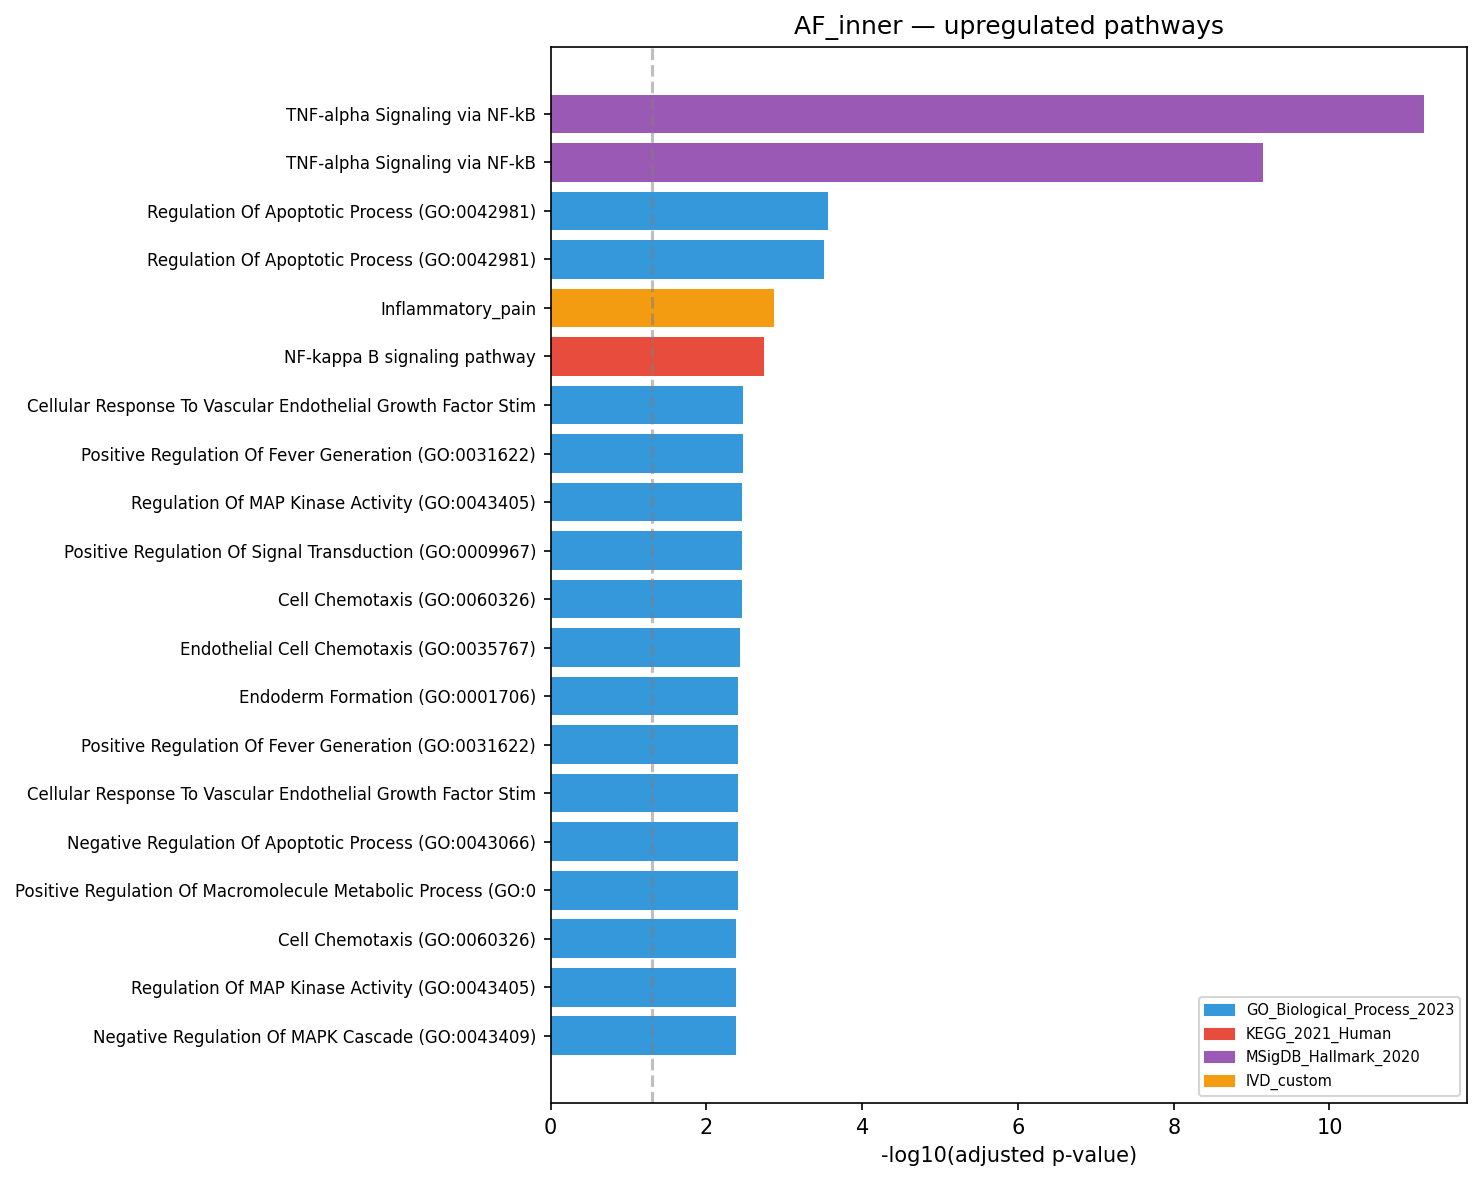

**AF outer (UP)**

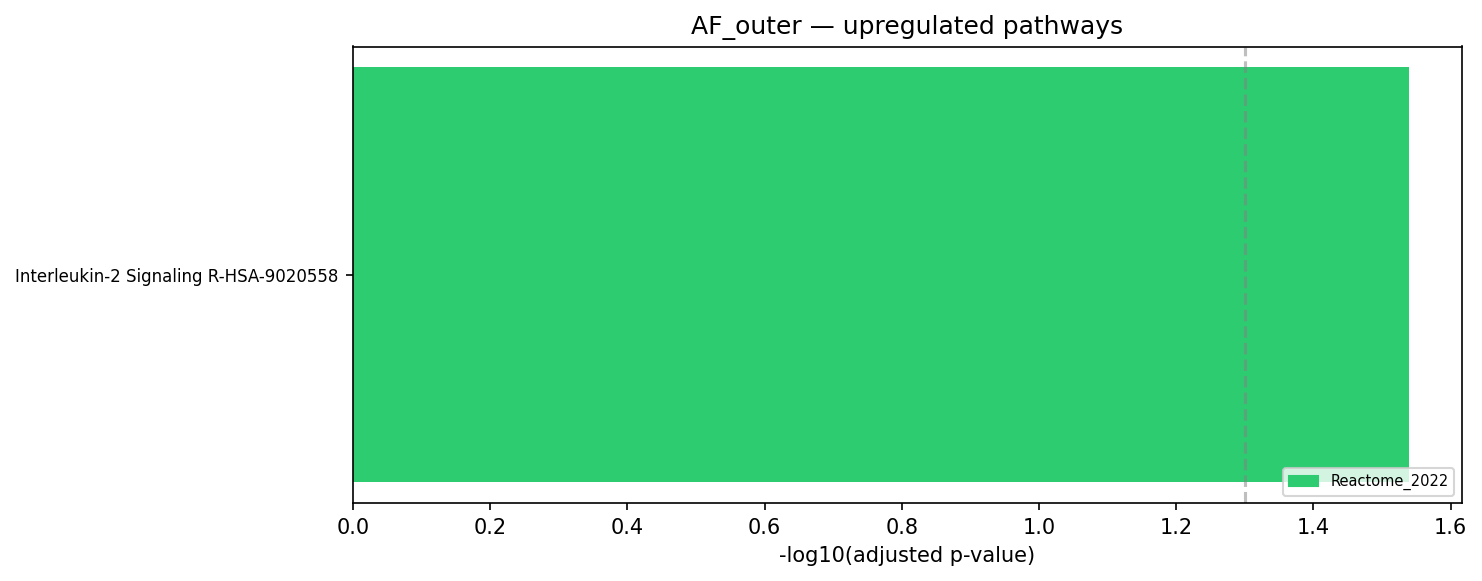

**Fibrochondrocyte chondroid (UP)**

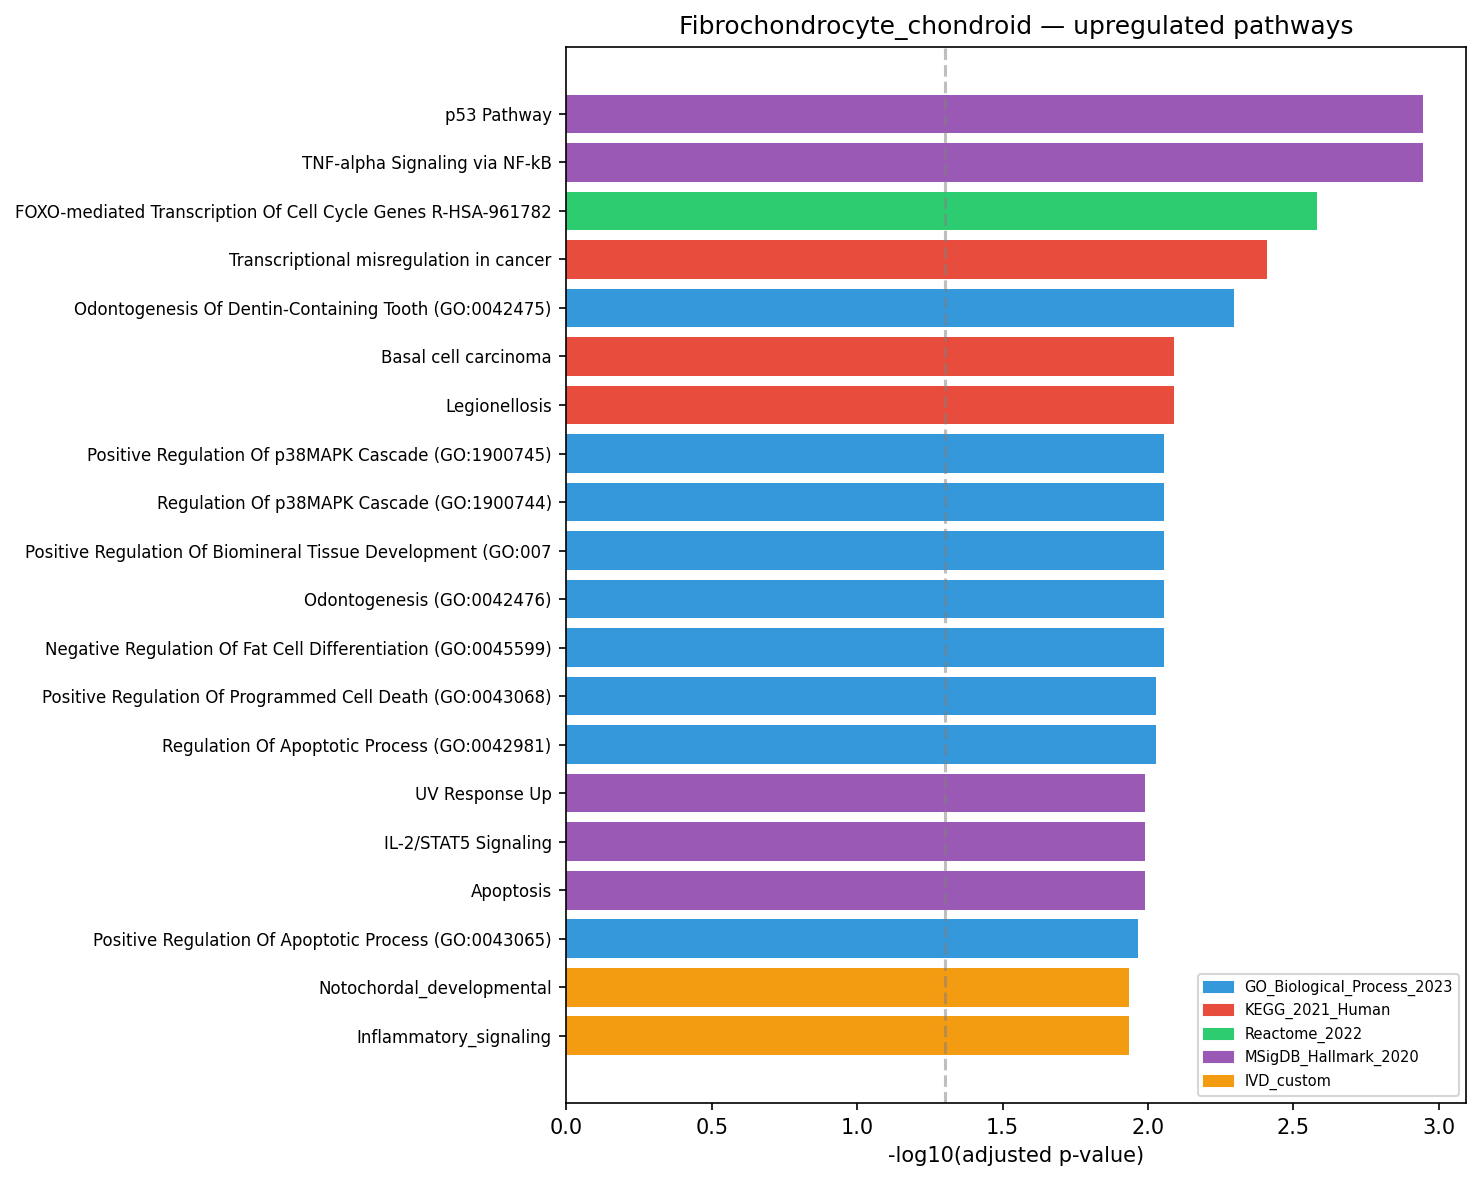

**Fibrochondrocyte stressed (UP)**

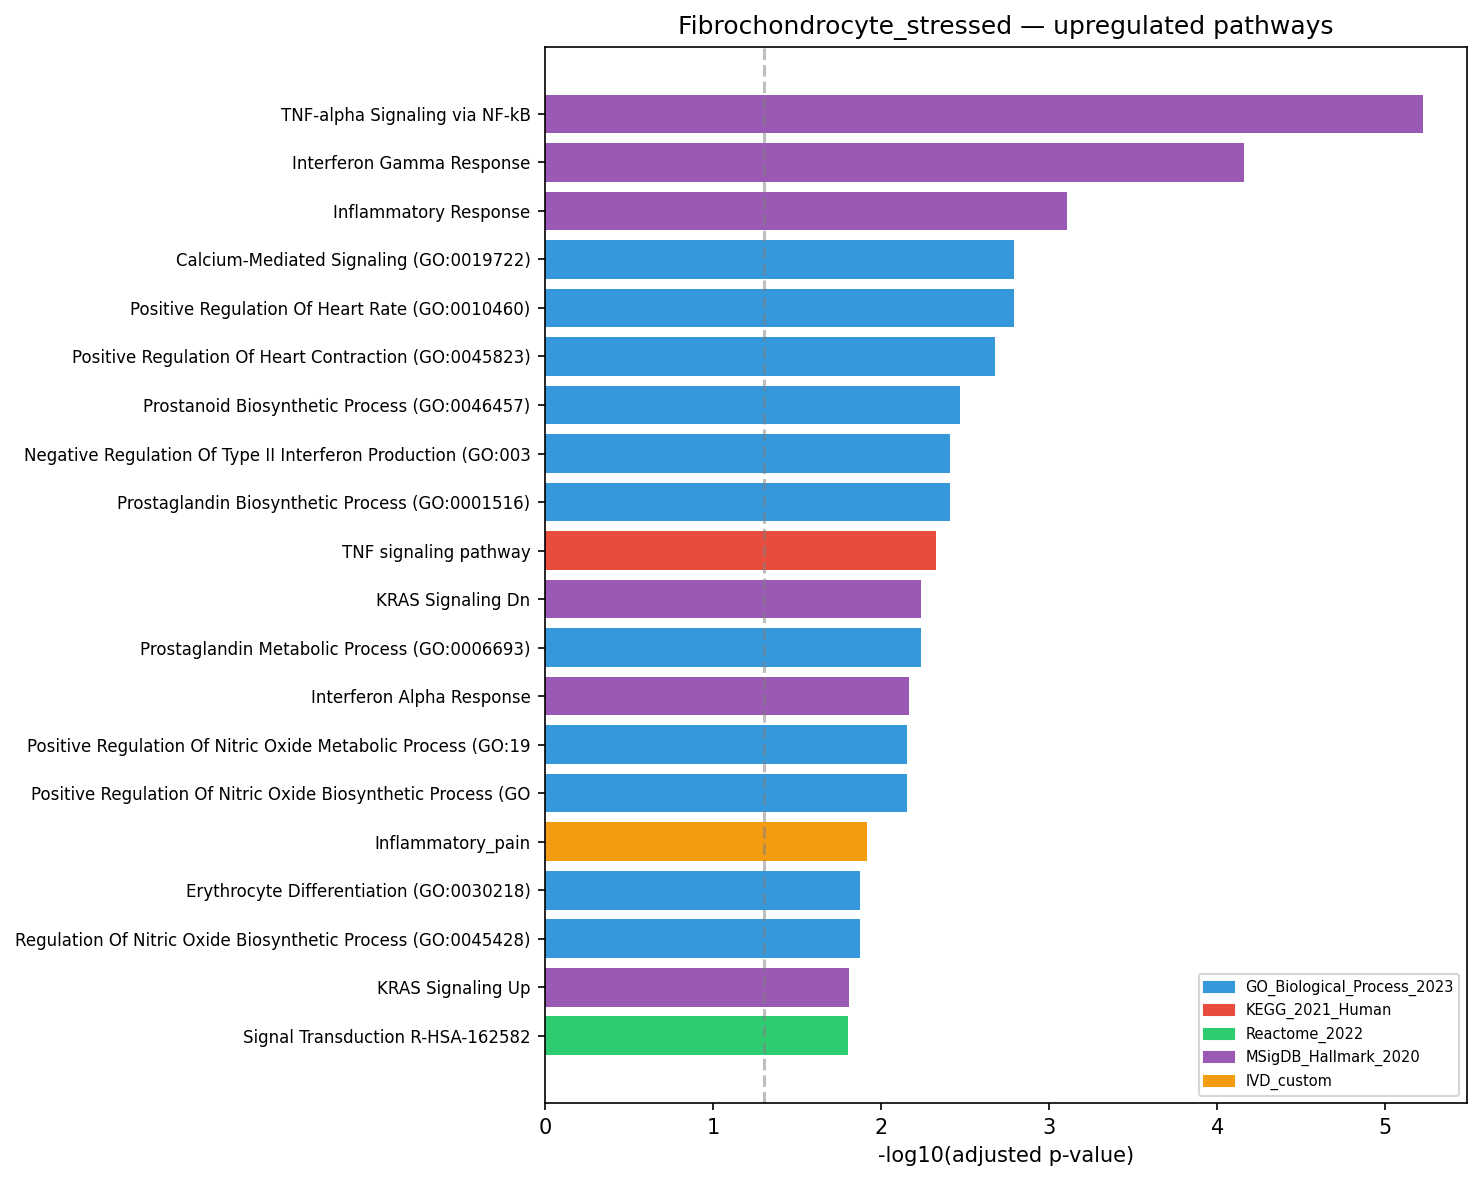

**NP fibrocartilaginous (UP)**

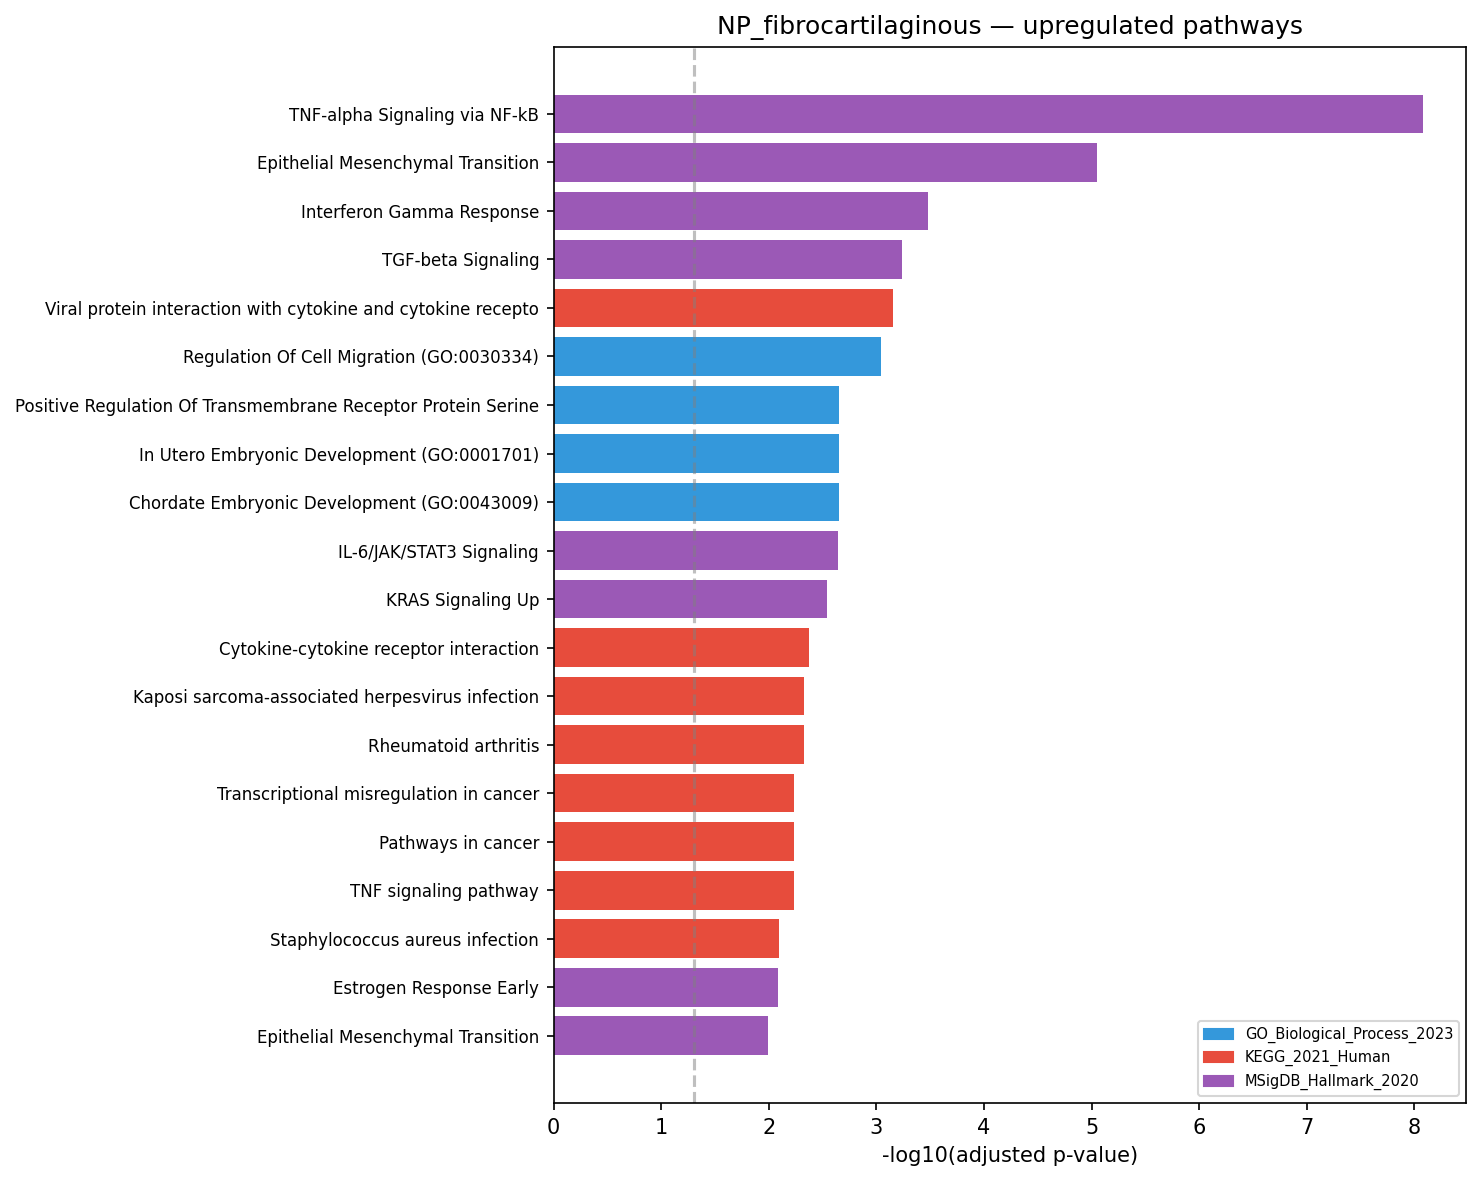

**NP mature chondrocyte (UP)**

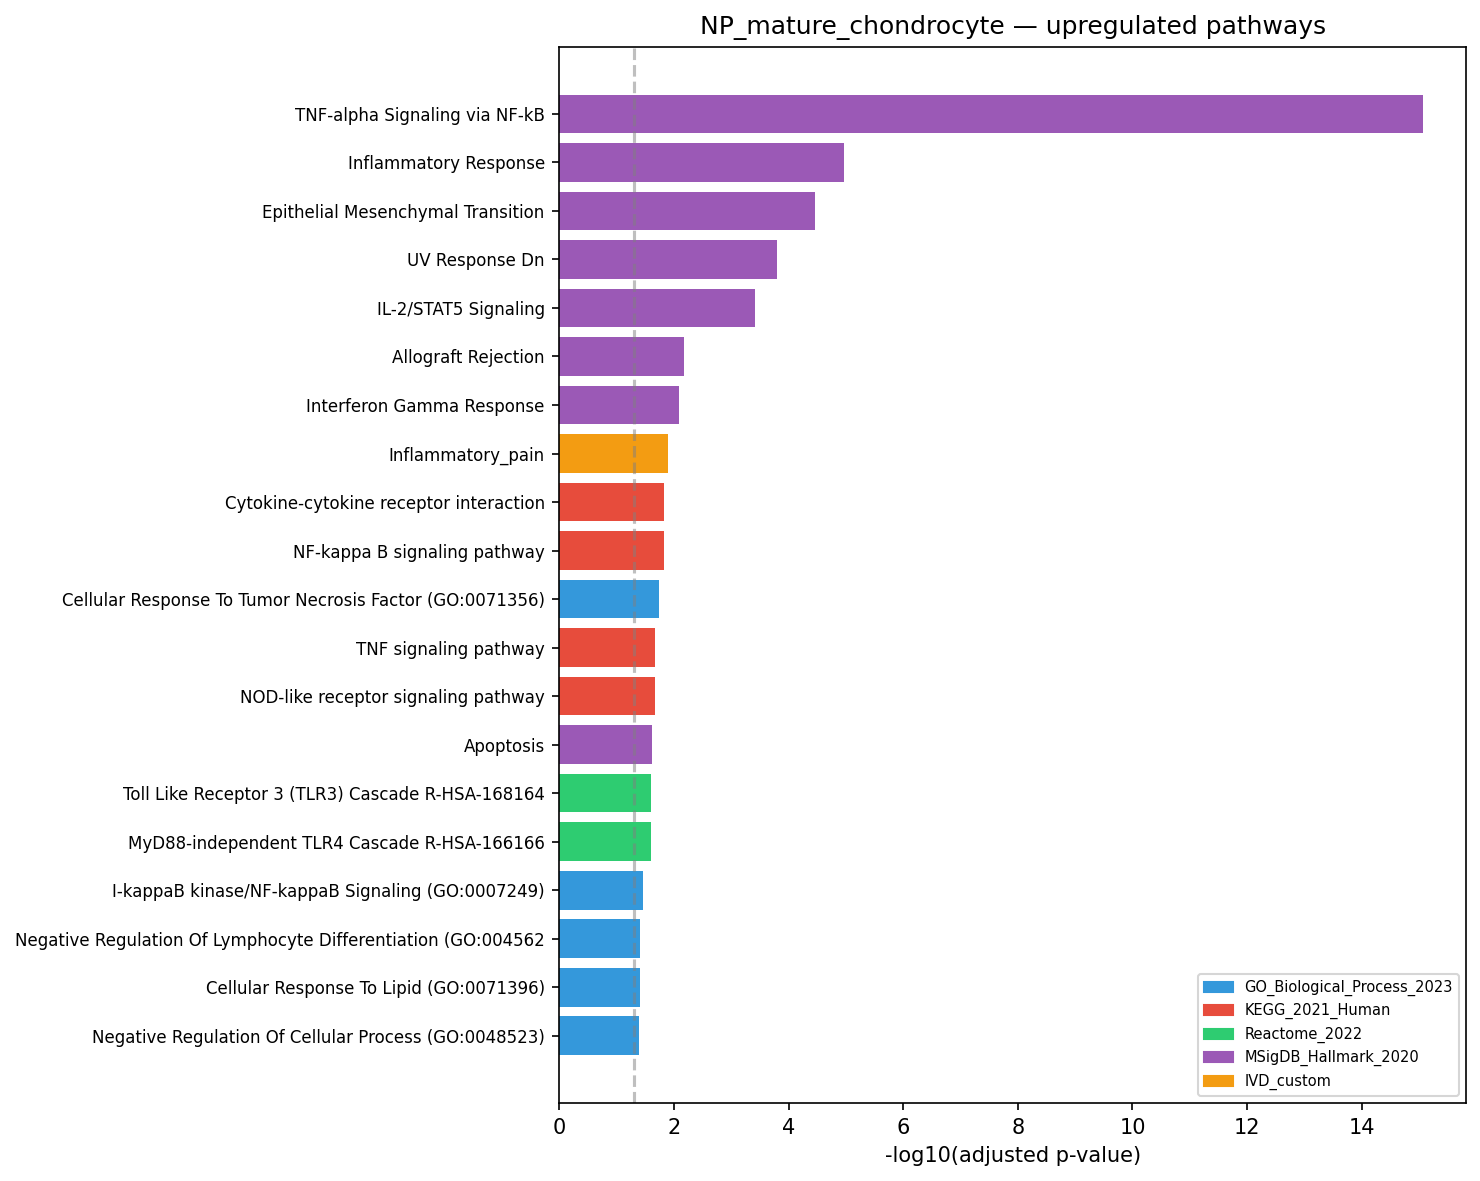

**NP notochordal (UP)**

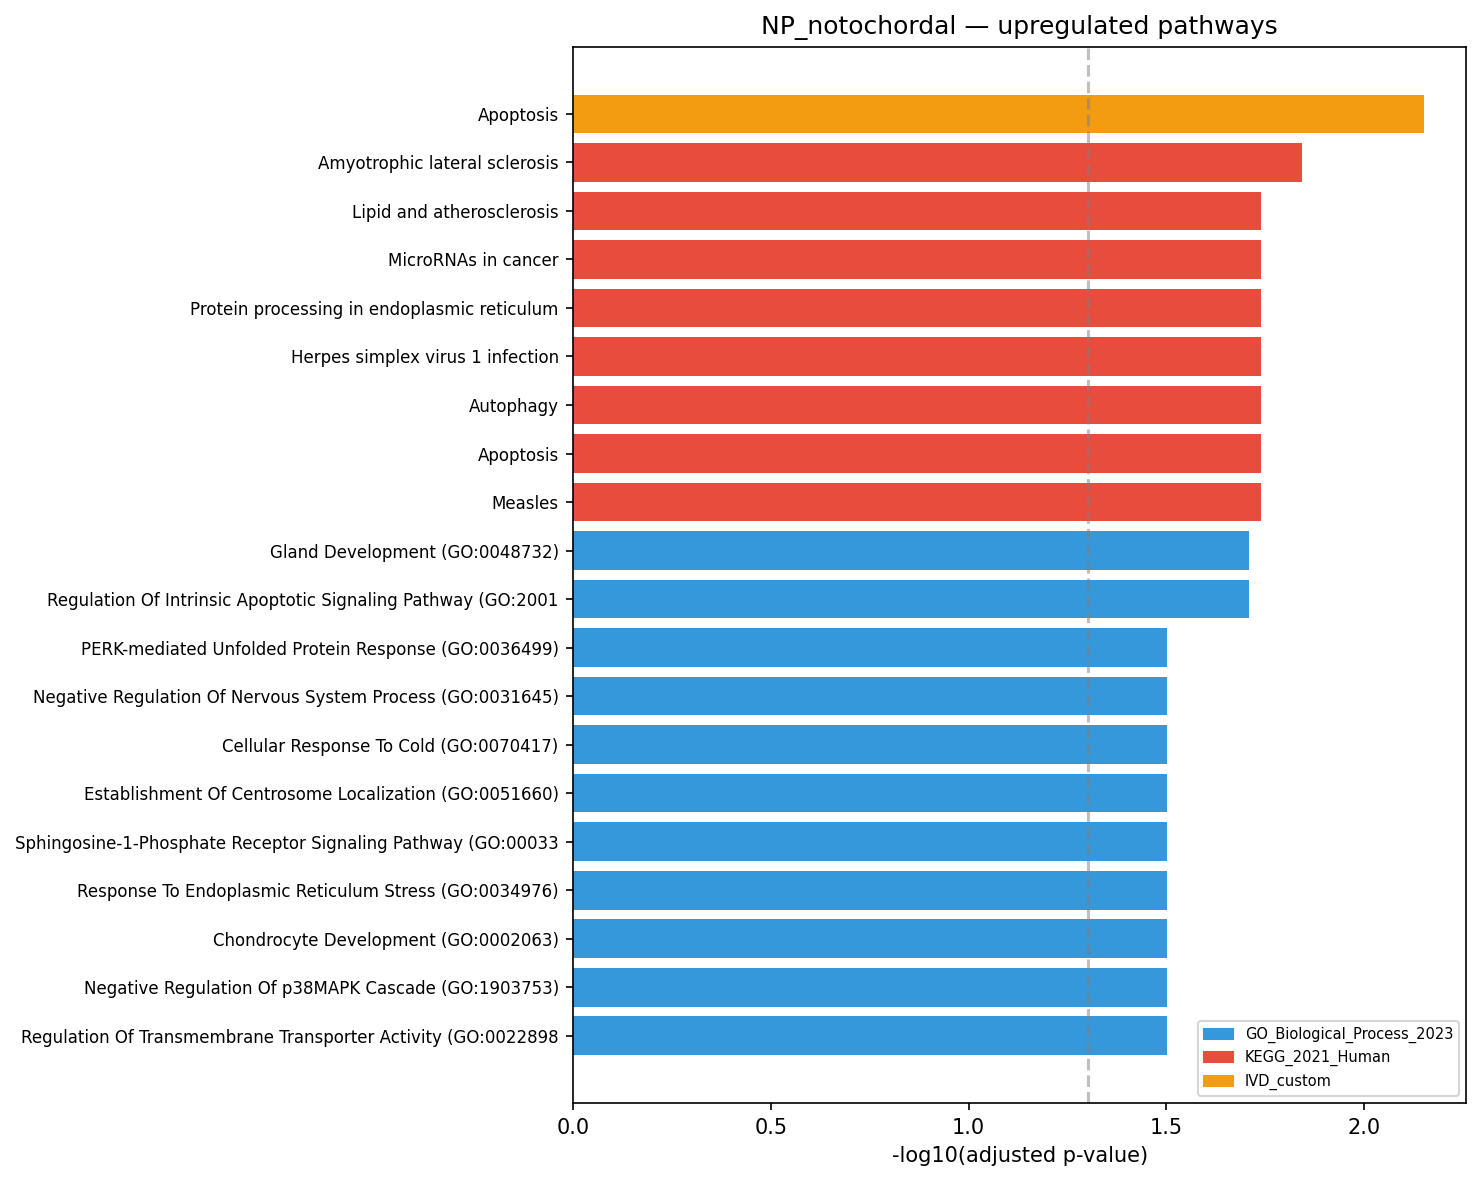

**T cell (UP)**

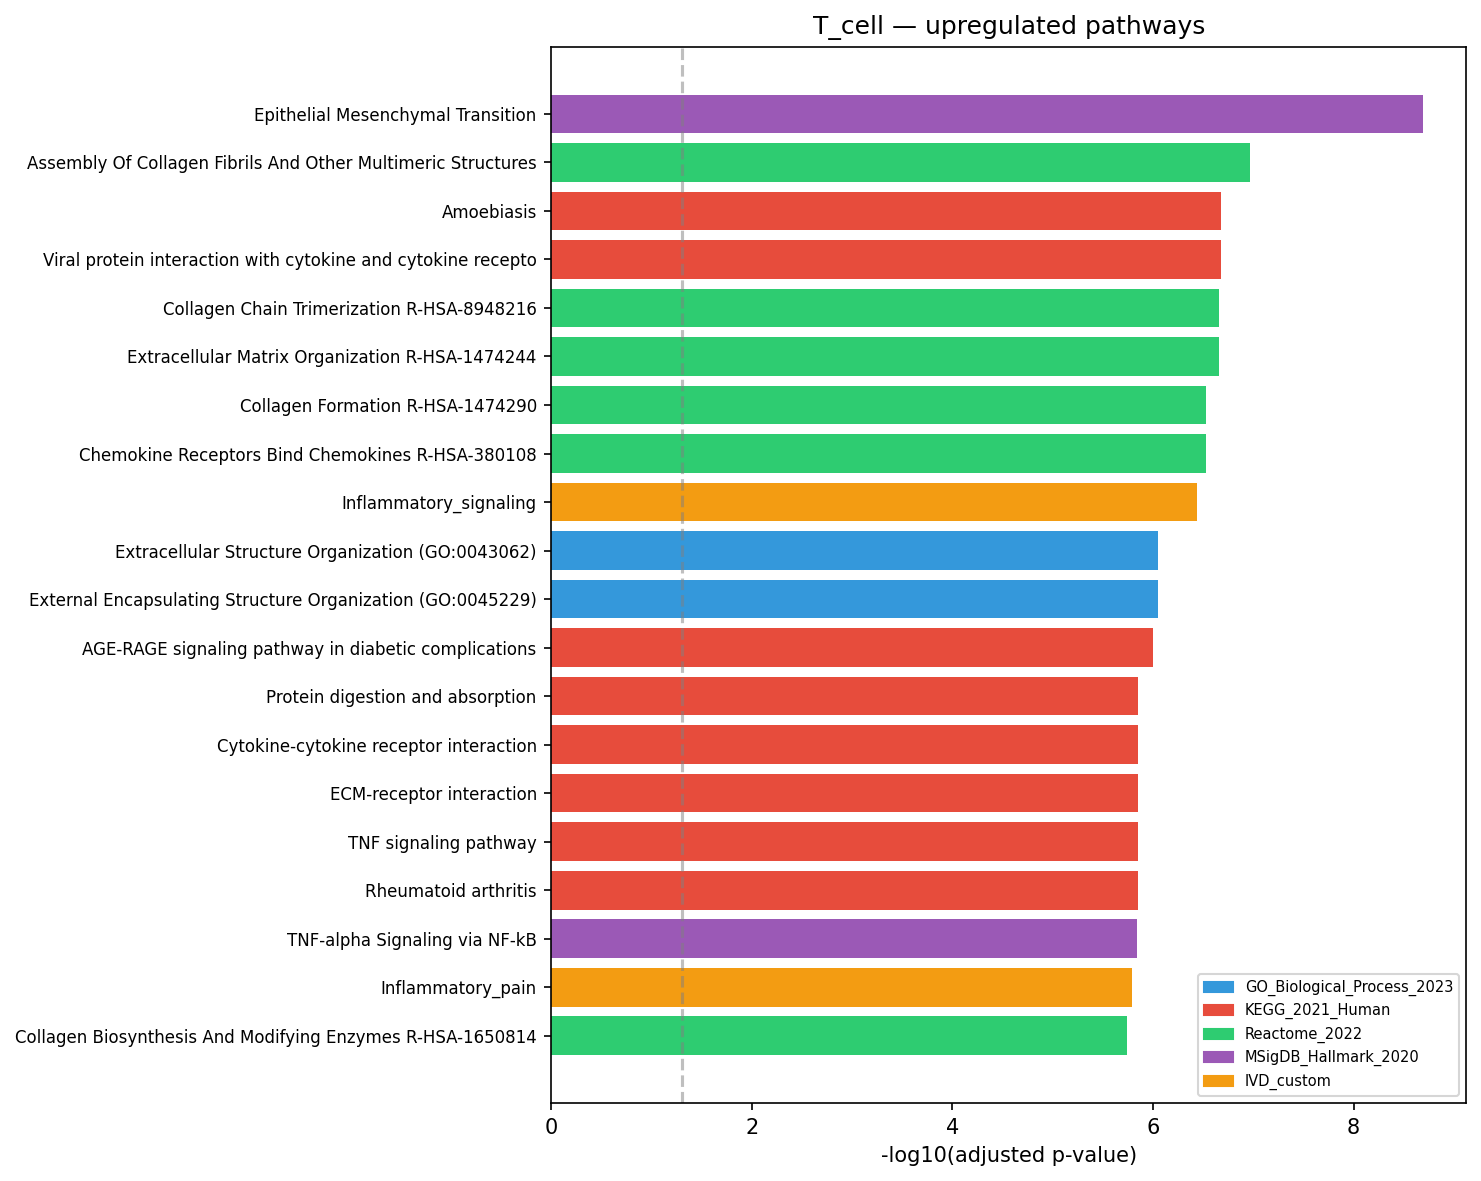

**unassigned (UP)**

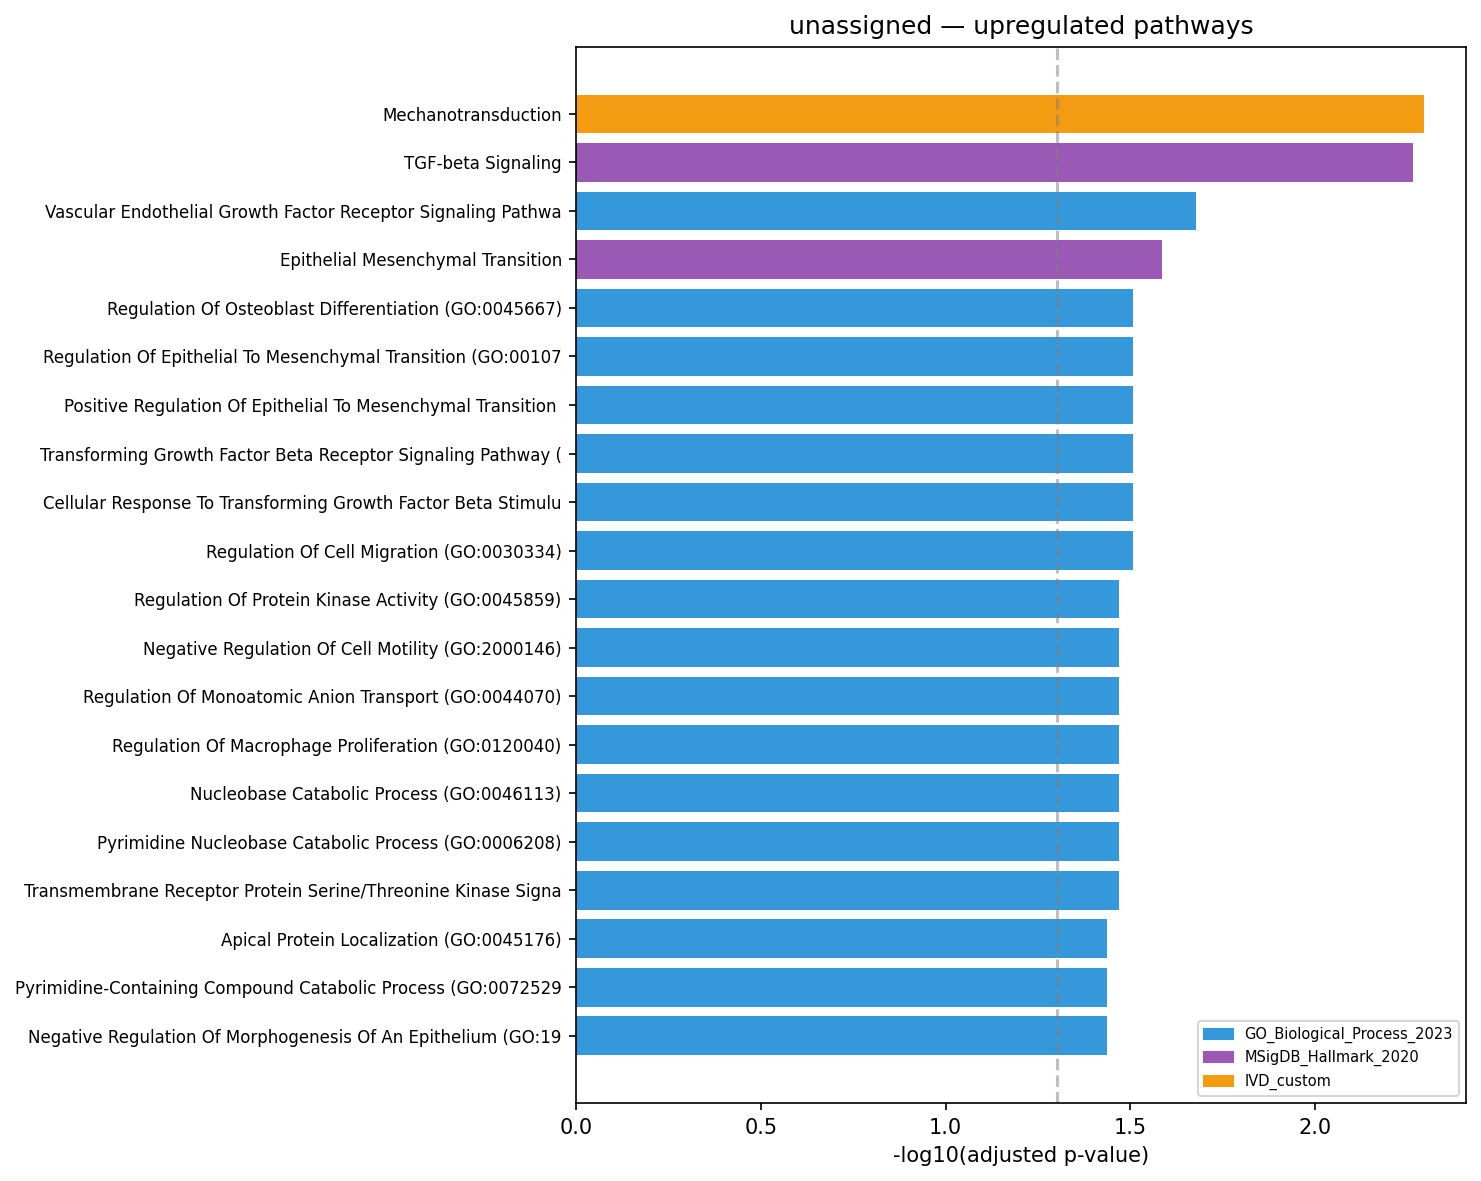

In [3]:
# Display ORA plots for upregulated genes
up_plots = sorted(PATHWAY_DIR.glob('enrichment_*_up.png'))
print(f'Upregulated enrichment plots: {len(up_plots)}')

for fpath in up_plots:
    label = fpath.stem.replace('enrichment_', '').replace('_up', ' (UP)').replace('_', ' ')
    display(Markdown(f'**{label}**'))
    display(Image(filename=str(fpath), width=800))

### ORA Dot Plots — Downregulated Genes

Downregulated enrichment plots: 7


**AF inner (DOWN)**

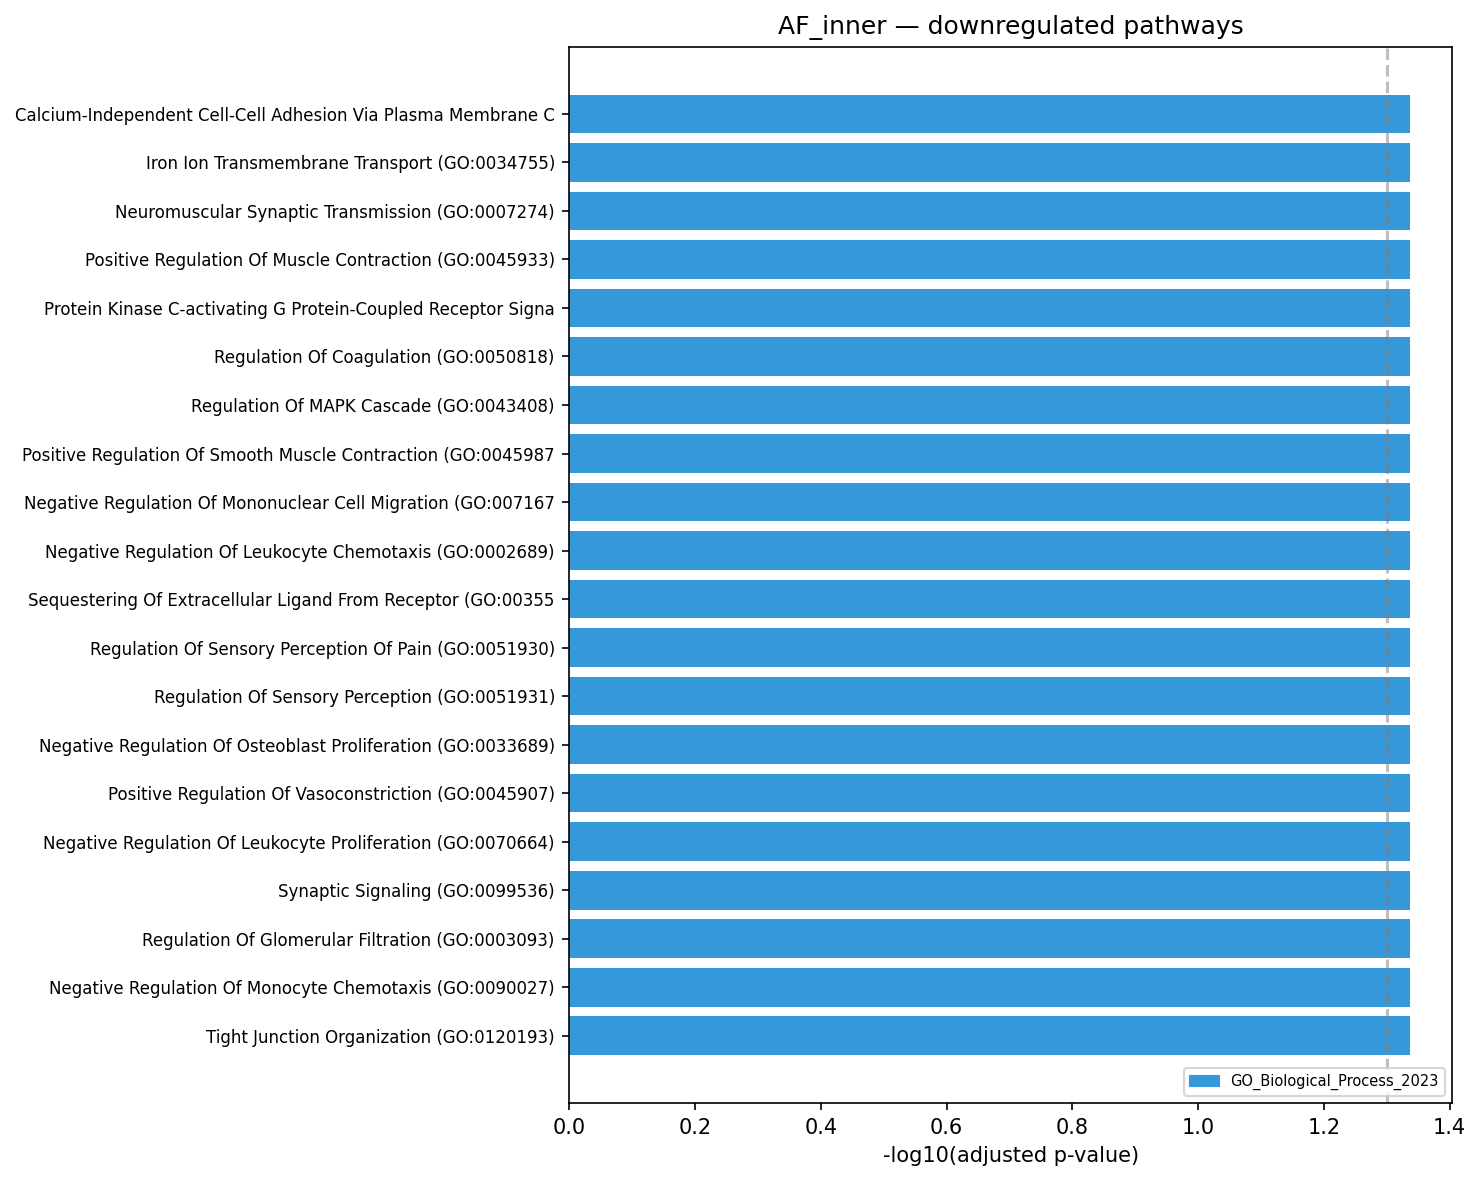

**AF outer (DOWN)**

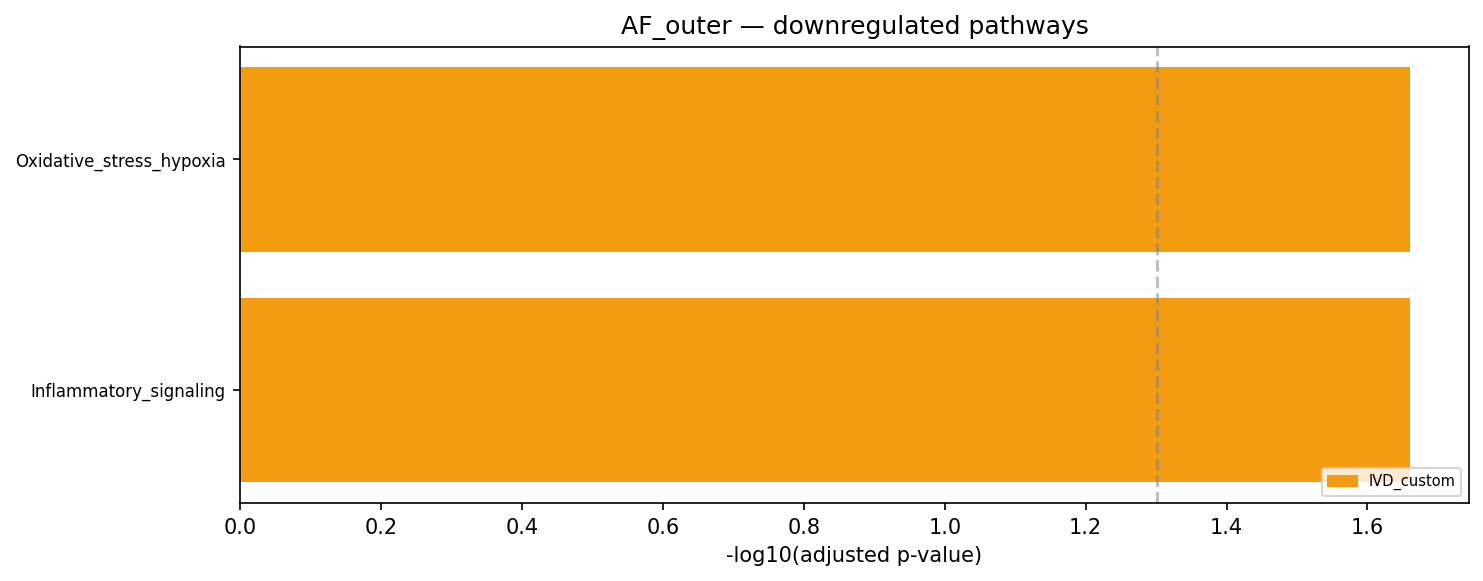

**Fibrochondrocyte chondroid (DOWN)**

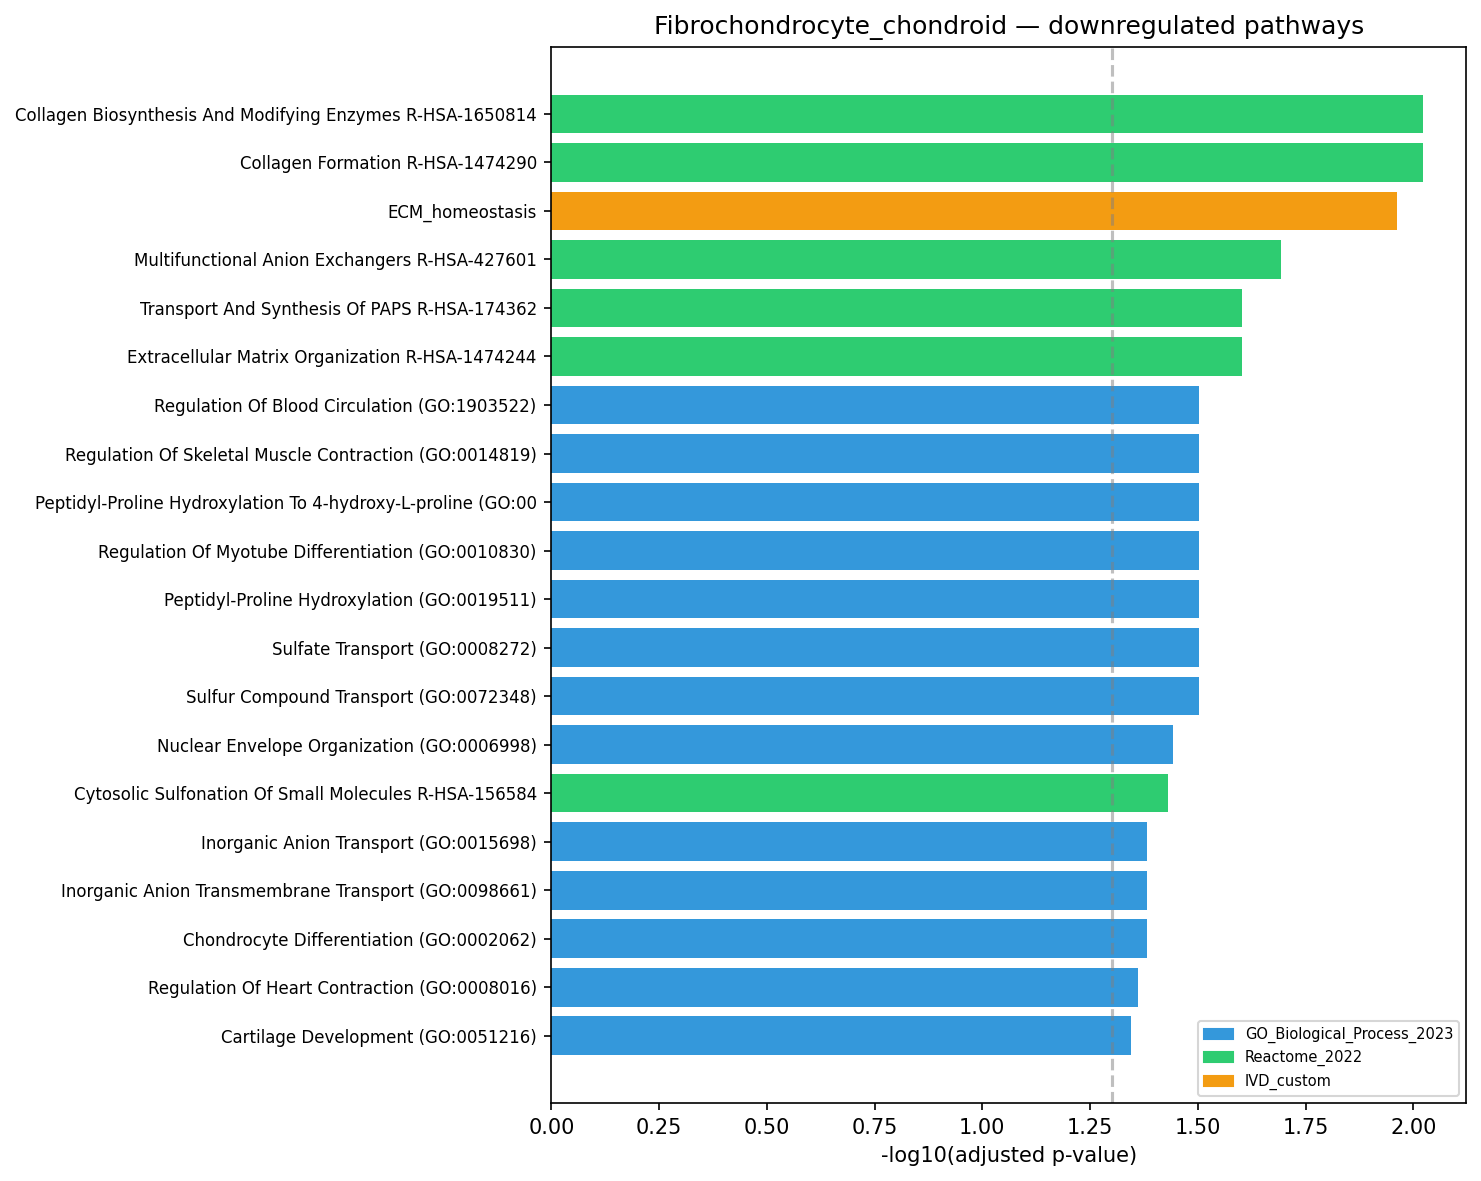

**NP fibrocartilaginous (DOWN)**

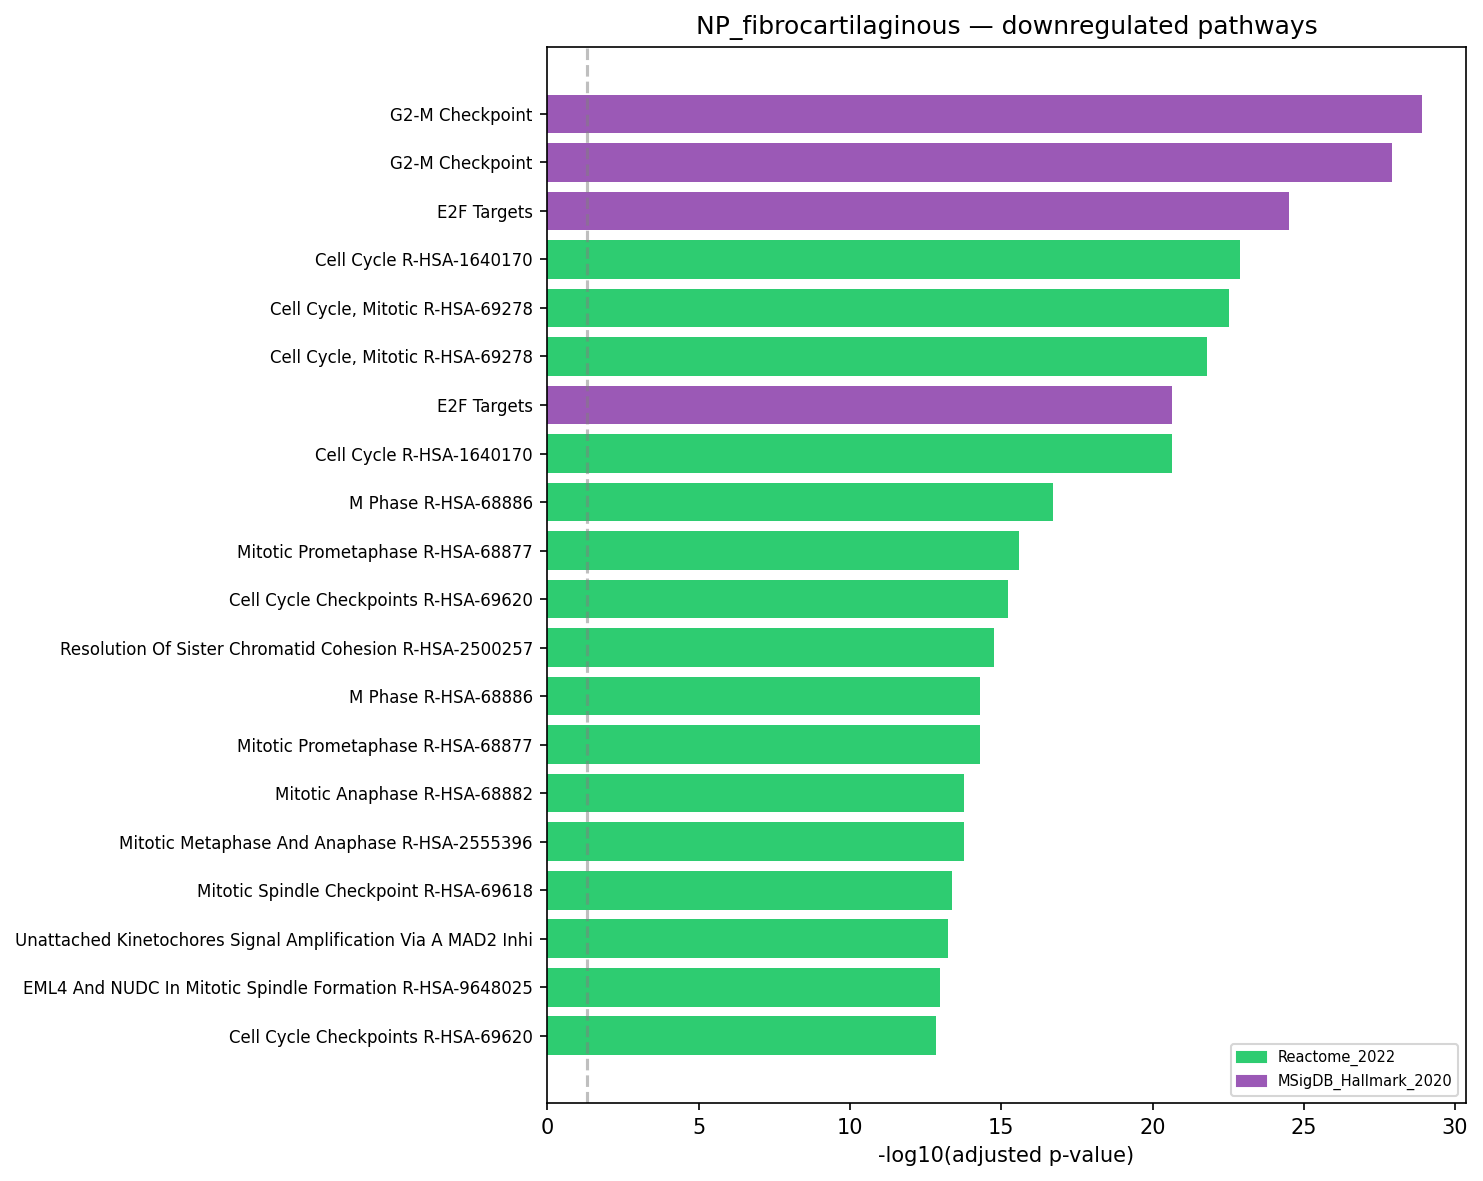

**NP mature chondrocyte (DOWN)**

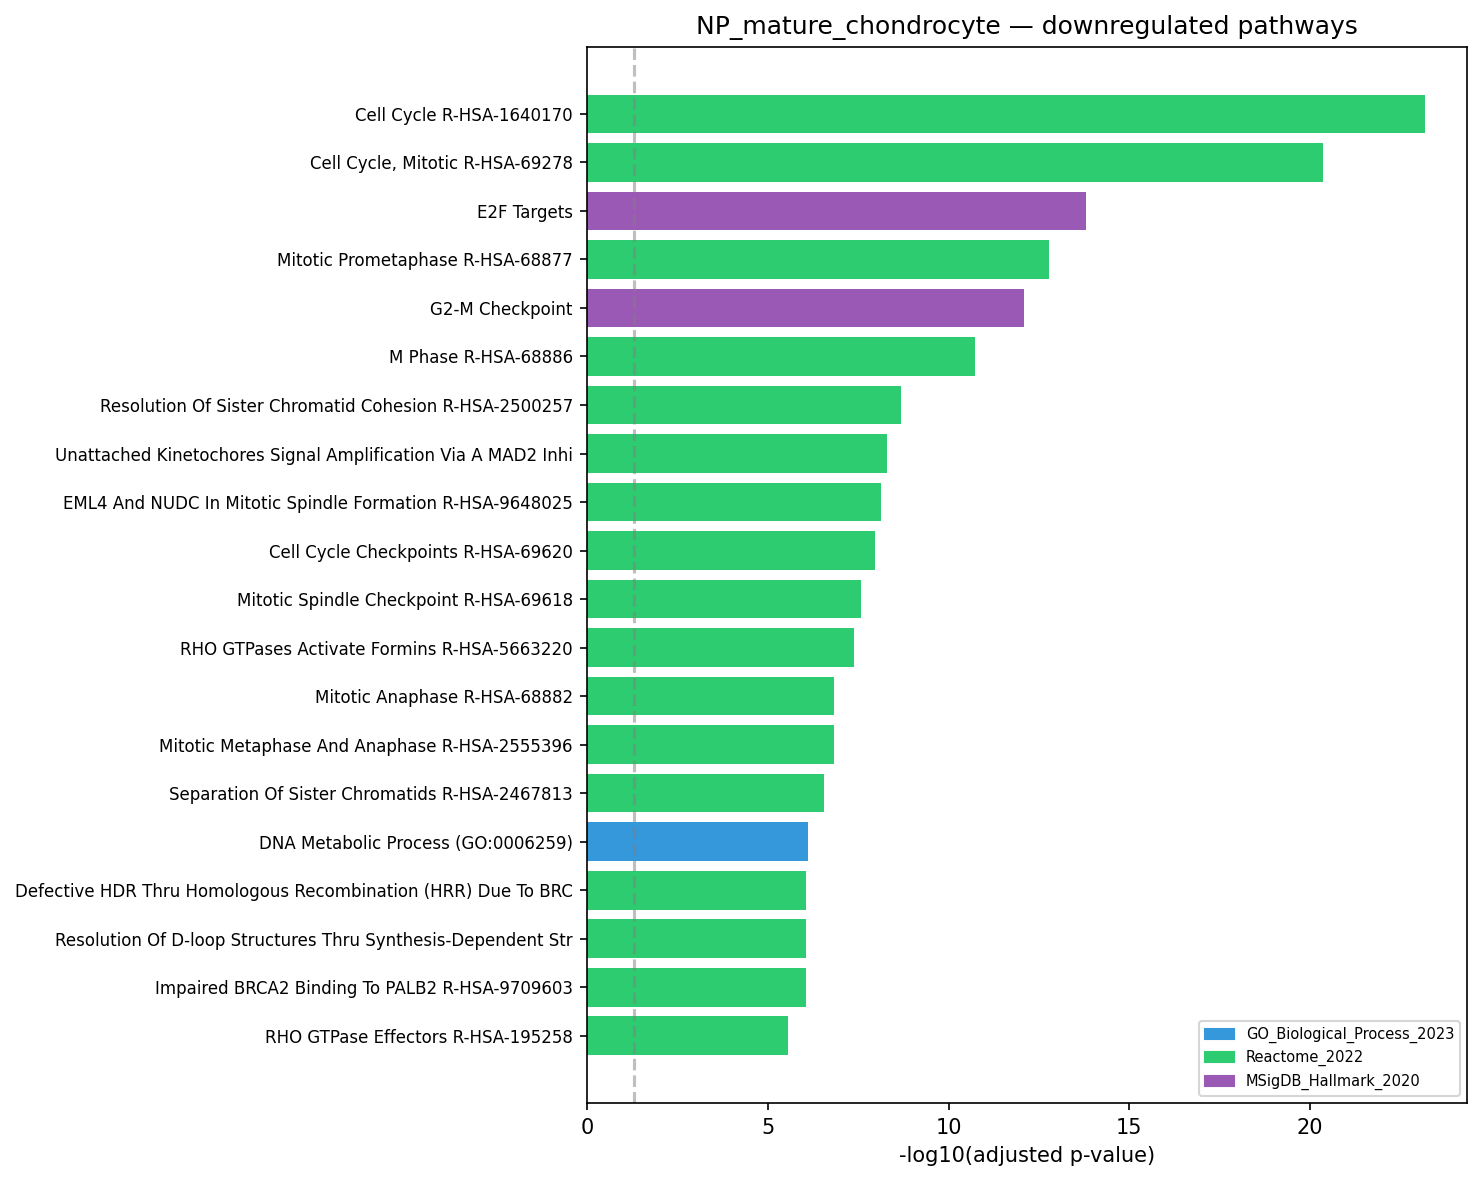

**NP notochordal (DOWN)**

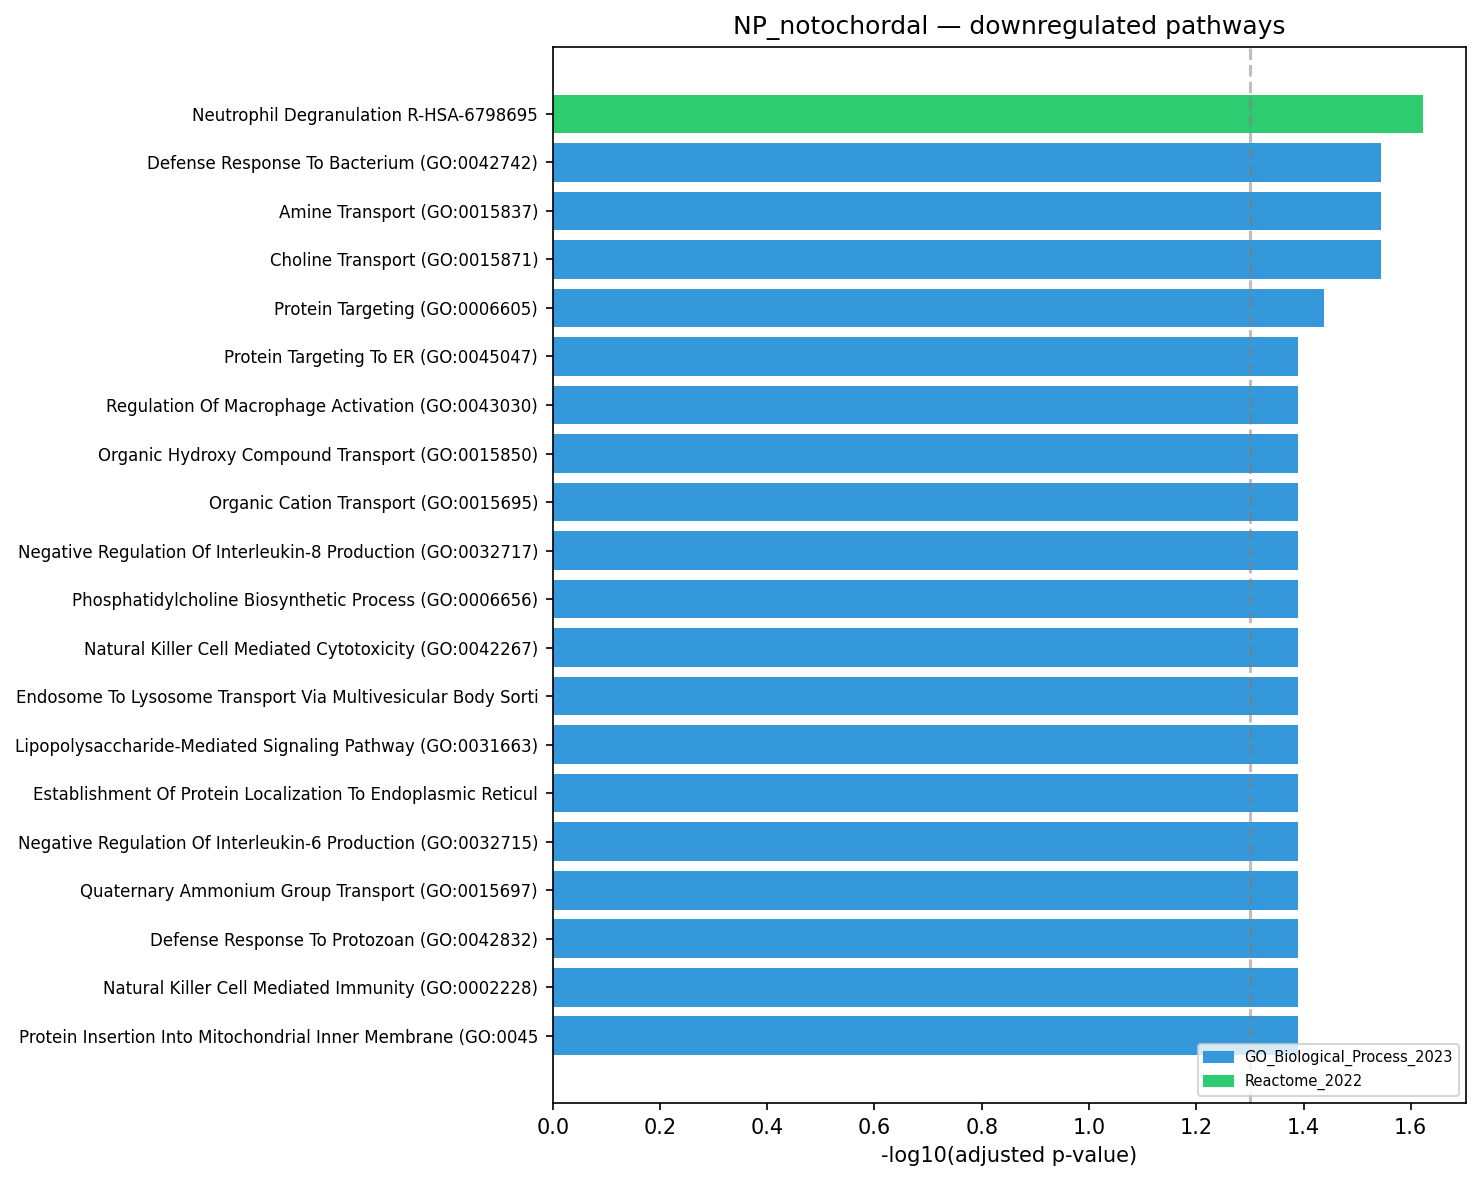

**T cell (DOWN)**

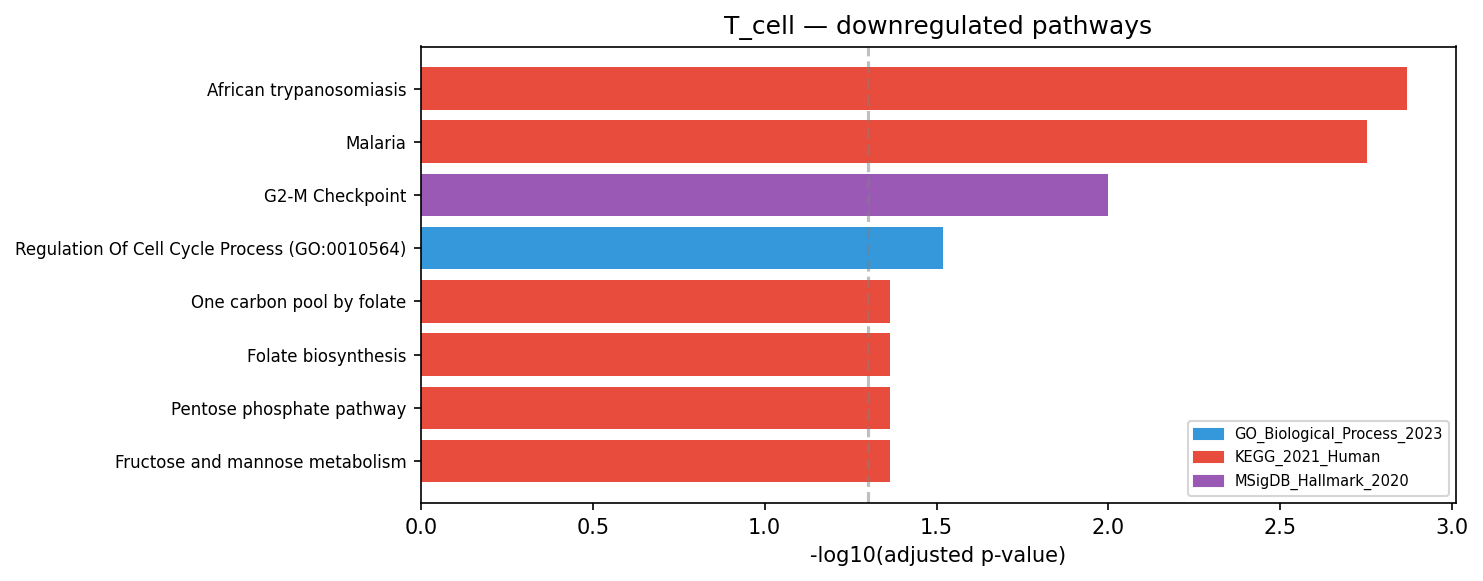

In [4]:
# Display ORA plots for downregulated genes
down_plots = sorted(PATHWAY_DIR.glob('enrichment_*_down.png'))
print(f'Downregulated enrichment plots: {len(down_plots)}')

for fpath in down_plots:
    label = fpath.stem.replace('enrichment_', '').replace('_down', ' (DOWN)').replace('_', ' ')
    display(Markdown(f'**{label}**'))
    display(Image(filename=str(fpath), width=800))

## Gene Set Enrichment Analysis (GSEA)

GSEA uses IVD-specific custom gene sets to assess pathway-level changes without
requiring a significance cutoff on individual genes. The heatmap shows
normalized enrichment scores (NES) across cell types.

In [5]:
# GSEA results summary
gsea_path = PATHWAY_DIR / 'gsea_results.tsv'
if gsea_path.exists():
    gsea = pd.read_csv(gsea_path, sep='\t')
    print(f'Total GSEA terms tested: {len(gsea)}')
    if 'padj' in gsea.columns:
        sig_gsea = gsea[gsea['padj'] < 0.05]
        print(f'Significant GSEA terms (padj < 0.05): {len(sig_gsea)}')
    elif 'pval' in gsea.columns:
        sig_gsea = gsea[gsea['pval'] < 0.05]
        print(f'Significant GSEA terms (pval < 0.05): {len(sig_gsea)}')
    
    # Show top terms
    display(gsea.head(20).style.set_caption('Top GSEA Results'))
else:
    print('GSEA results file not found')

Total GSEA terms tested: 68839


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,cell_type,comparison,library
0,prerank,Cellular Response To Hypoxia (GO:0071456),0.727090,2.271751,0.000000,0.001252,0.001000,22/67,7.90%,PTGS2;VEGFA;EGLN3;MT3;PMAIP1;NDRG1;PLK3;HILPDA;RORA;TWIST1;MDM2;EGLN1;NDNF;NKX3-1;CPEB2;PGK1;FAM162A;AK4;UBQLN1;SIRT1;HMOX1;HIF1A,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
1,prerank,Cellular Response To Decreased Oxygen Levels (GO:0036294),0.722145,2.261060,0.000000,0.001879,0.002000,22/68,7.90%,PTGS2;VEGFA;EGLN3;MT3;PMAIP1;NDRG1;HILPDA;RORA;TWIST1;MDM2;EGLN1;NDNF;NKX3-1;CPEB2;PGK1;FAM162A;CPEB4;AK4;UBQLN1;SIRT1;HMOX1;HIF1A,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
2,prerank,Positive Regulation Of Myeloid Leukocyte Differentiation (GO:0002763),0.745780,2.037434,0.001905,0.094354,0.165000,5/31,0.43%,TNFSF11;LEF1;LIF;PPP3CA;HLA-DRB1,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
3,prerank,Cellular Response To Vascular Endothelial Growth Factor Stimulus (GO:0035924),0.760830,2.025597,0.000000,0.089866,0.203000,10/26,11.26%,VEGFA;SPRY2;EGR3;SPHK1;FLT1;MT1G;PGF;ERN1;RELA;MAP2K3,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
4,prerank,Regulation Of Transferase Activity (GO:0051338),-0.832579,-1.987499,0.000000,1.000000,0.558000,1/15,0.01%,SPTSSB,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
5,prerank,Regulation Of Vascular Endothelial Growth Factor Production (GO:0010574),0.818406,1.980478,0.000000,0.139861,0.377000,3/17,1.66%,PTGS2;RORA;CYP1B1,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
6,prerank,Positive Regulation Of Vascular Endothelial Growth Factor Production (GO:0010575),0.818406,1.980478,0.000000,0.139861,0.377000,3/17,1.66%,PTGS2;RORA;CYP1B1,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
7,prerank,Collagen Fibril Organization (GO:0030199),-0.648953,-1.969348,0.000000,0.748655,0.619000,10/39,5.86%,GREM1;COL14A1;LOXL1;LOXL4;CRTAP;ADAMTS3;SCX;SERPINH1;P3H4;PXDN,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
8,prerank,Regulation Of Neuroinflammatory Response (GO:0150077),0.864796,1.968785,0.000000,0.145109,0.436000,4/15,2.61%,PTGS2;SPHK1;PLCG2;TNFRSF1B,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023
9,prerank,Positive Regulation Of Glial Cell Differentiation (GO:0045687),0.815625,1.958412,0.000000,0.152177,0.490000,7/17,7.03%,BMP2;MDK;EGR2;SERPINE2;TNFRSF1B;CXCR4;CLCF1,AF_inner,healthy_vs_degenerated_all,GO_Biological_Process_2023


**GSEA Heatmap — IVD Custom Gene Sets**

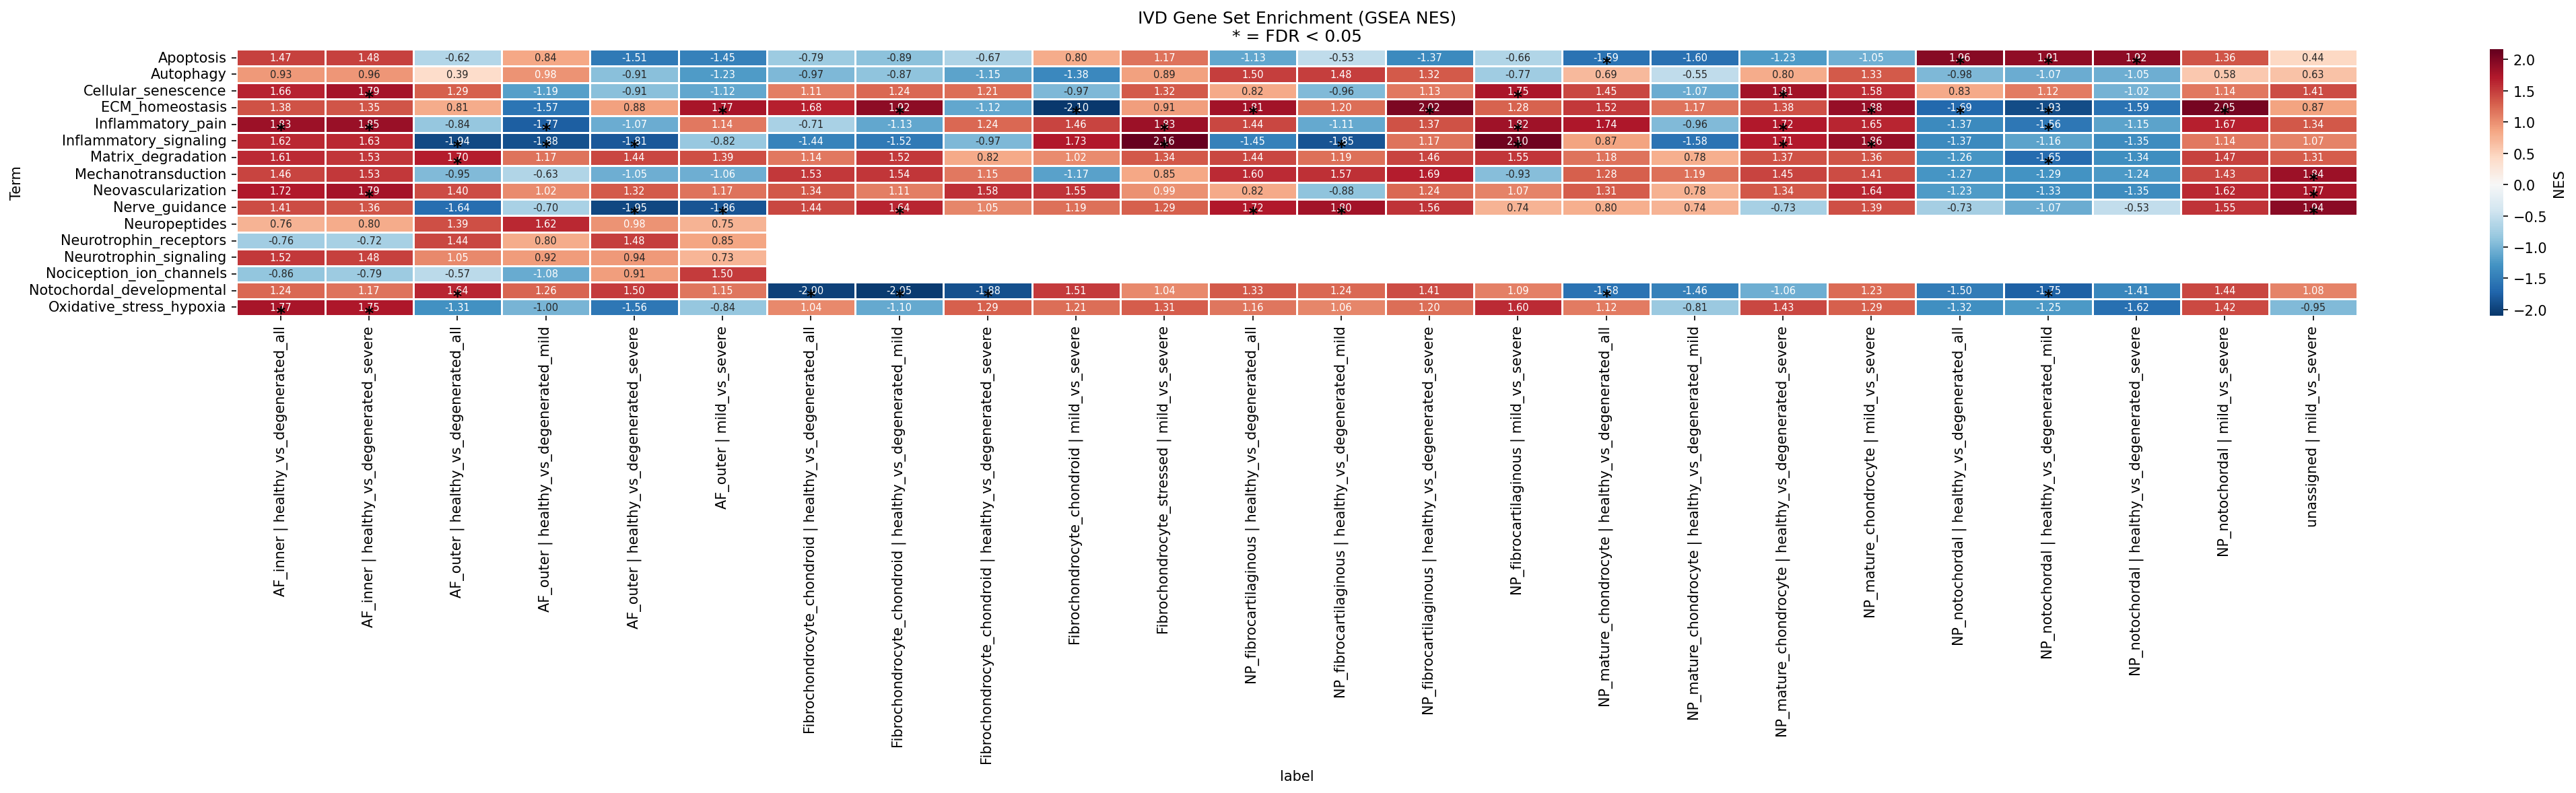

In [6]:
# GSEA heatmap
gsea_heatmap = PATHWAY_DIR / 'gsea_ivd_custom_heatmap.png'
if gsea_heatmap.exists():
    display(Markdown('**GSEA Heatmap — IVD Custom Gene Sets**'))
    display(Image(filename=str(gsea_heatmap), width=900))
else:
    print('GSEA heatmap not found')

## Transcription Factor Activity

TF activity is inferred from target gene expression using DoRothEA regulons.
The heatmap shows TFs with significantly altered activity between healthy and
degenerated conditions across cell types.

In [7]:
# TF activity results
tf_path = TF_DIR / 'tf_activity_results.tsv'
if tf_path.exists():
    tf = pd.read_csv(tf_path, sep='\t')
    print(f'Total TFs tested: {tf["tf"].nunique() if "tf" in tf.columns else len(tf)}')
    
    # Count significant TFs
    for col in ['padj', 'pval', 'p_value']:
        if col in tf.columns:
            sig_tf = tf[tf[col] < 0.05]
            print(f'Significant TFs ({col} < 0.05): {len(sig_tf)}')
            display(sig_tf.head(20).style.set_caption('Top Significant TFs'))
            break
    else:
        display(tf.head(20).style.set_caption('TF Activity Results (Top 20)'))
else:
    print('TF activity results file not found')

Total TFs tested: 700
Significant TFs (padj < 0.05): 246


,cell_type,comparison,tf,activity,pvalue,n_targets,n_de_targets,concordant_up,concordant_down,padj
4,AF_inner,healthy_vs_degenerated_all,STAT5A,0.017857,0.000060,168,5,4,1,0.002605
6,AF_inner,healthy_vs_degenerated_all,RELA,0.022727,0.000000,440,10,10,0,0.000017
9,AF_inner,healthy_vs_degenerated_all,SP1,0.005698,0.000006,1053,12,9,3,0.000363
10,AF_inner,healthy_vs_degenerated_all,TP53,0.000000,0.000001,847,12,6,6,0.000074
14,AF_inner,healthy_vs_degenerated_all,STAT1,0.016194,0.003313,247,4,4,0,0.036810
15,AF_inner,healthy_vs_degenerated_all,STAT3,0.005747,0.000211,348,6,4,2,0.006724
18,AF_inner,healthy_vs_degenerated_all,CREB1,0.025352,0.000000,355,11,10,1,0.000001
20,AF_inner,healthy_vs_degenerated_all,NFATC2,0.049180,0.000476,61,3,3,0,0.009797
22,AF_inner,healthy_vs_degenerated_all,FOS,0.019608,0.000418,255,5,5,0,0.009614
26,AF_inner,healthy_vs_degenerated_all,HBP1,0.051282,0.004290,39,2,2,0,0.044166


**TF Activity Heatmap — Healthy vs Degenerated**

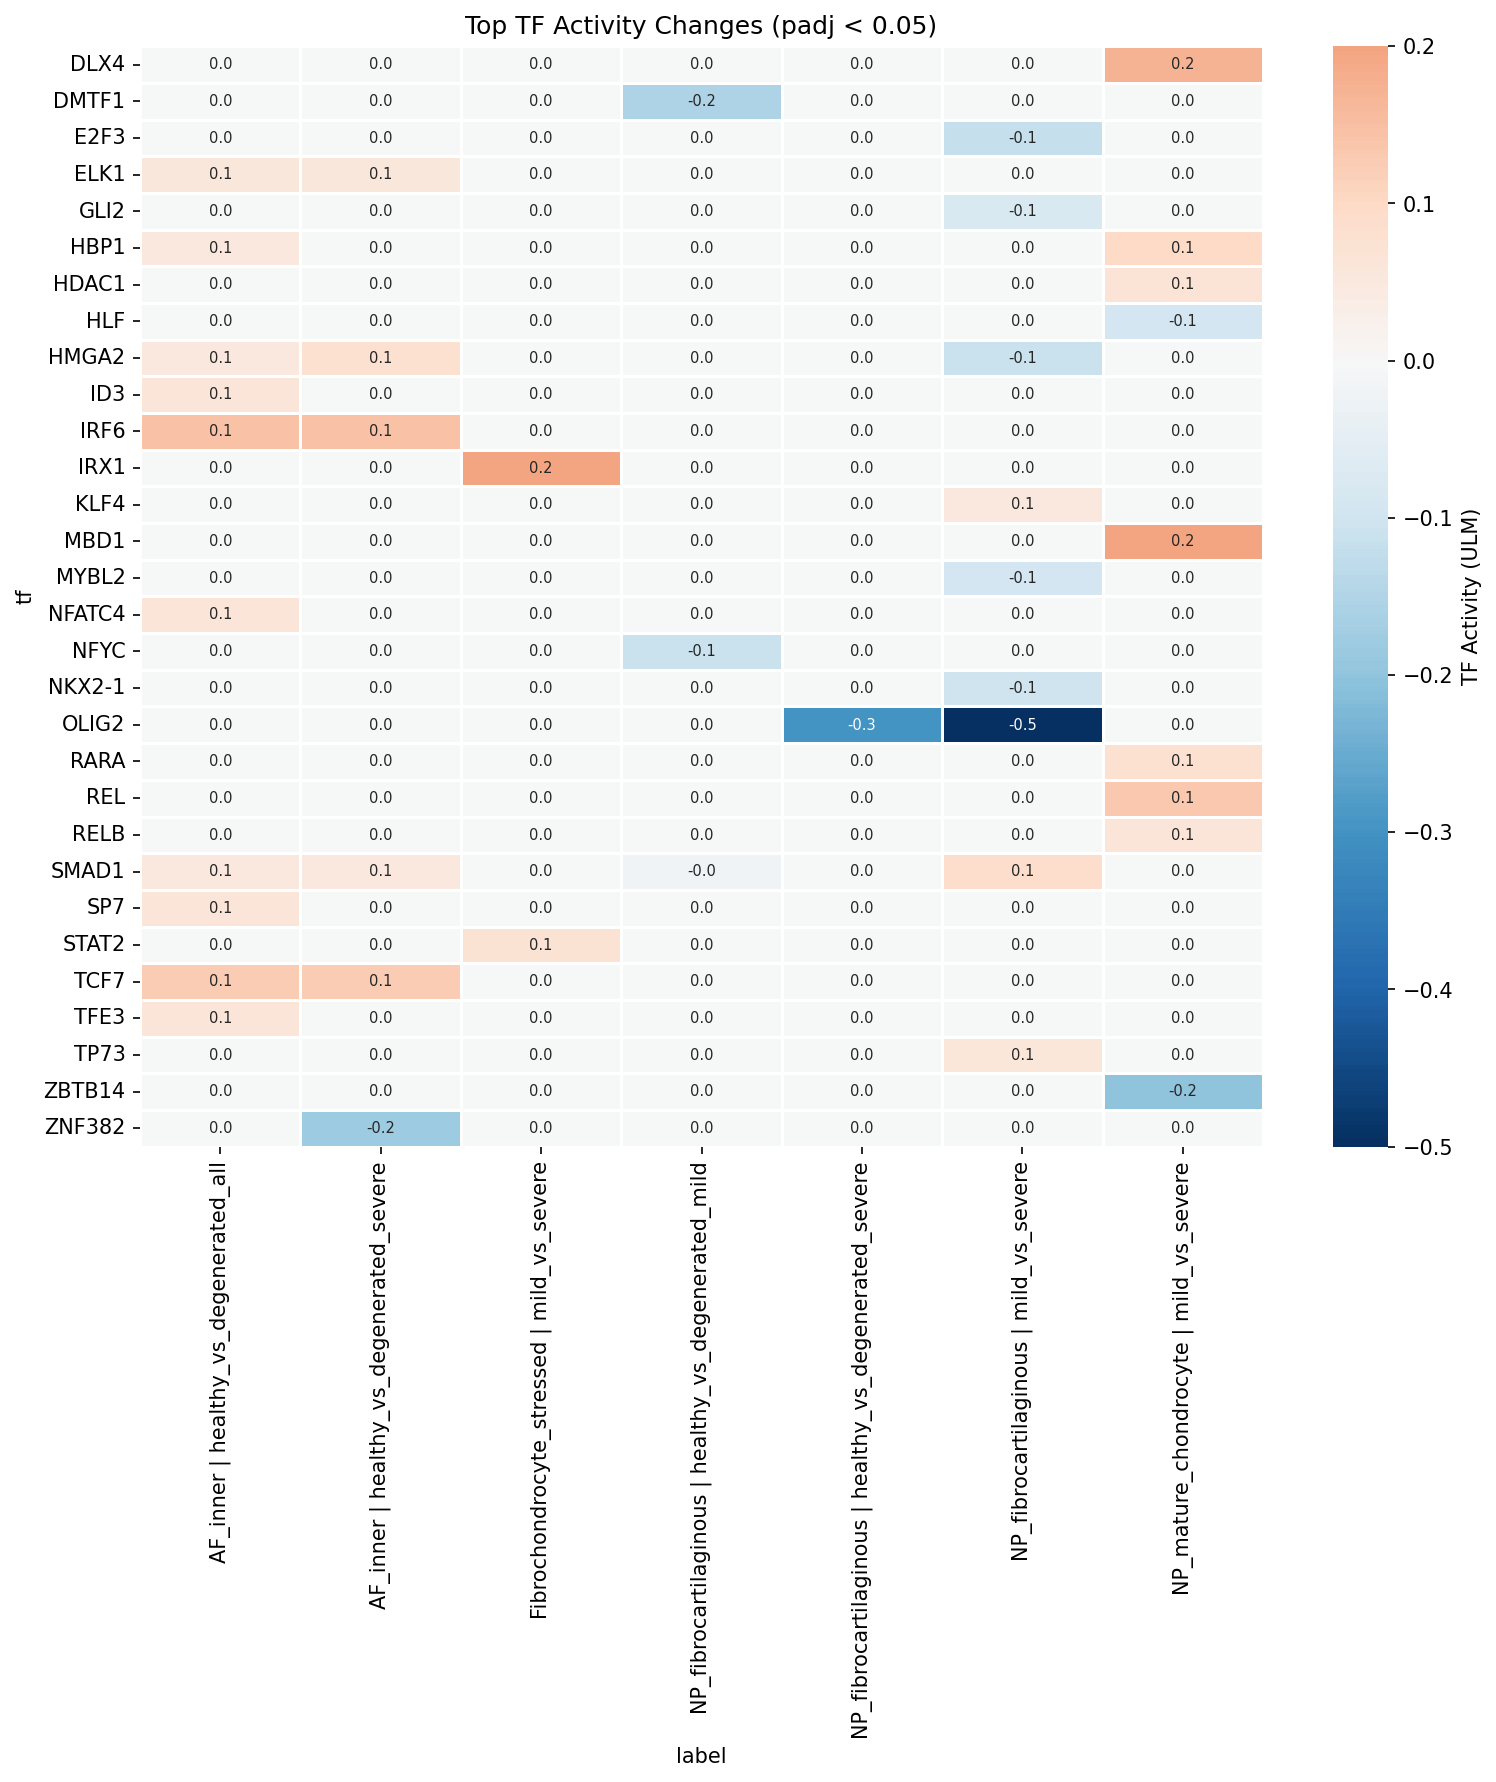

In [8]:
# TF activity heatmap
tf_heatmap = TF_DIR / 'tf_activity_heatmap.png'
if tf_heatmap.exists():
    display(Markdown('**TF Activity Heatmap — Healthy vs Degenerated**'))
    display(Image(filename=str(tf_heatmap), width=900))
else:
    print('TF activity heatmap not found')

## Pain-Related Gene Analysis

A curated set of pain-related genes (nociceptive signaling, inflammatory
mediators, ion channels, neurotrophins) was tested for differential expression
in degeneration. This directly addresses the clinical relevance of IVD
degeneration as a pain condition.

In [9]:
# Pain gene results
pain_path = RESULTS / 'pain_genes.tsv'
if pain_path.exists():
    pain = pd.read_csv(pain_path, sep='\t')
    print(f'Total pain gene entries: {len(pain)}')
    print(f'Unique pain genes tested: {pain["gene"].nunique()}')
    
    # Significant pain genes
    if 'significant' in pain.columns:
        sig_pain = pain[pain['significant'] == True]
        print(f'Significant pain genes: {sig_pain["gene"].nunique()}')
        if len(sig_pain) > 0:
            cols = [c for c in ['gene', 'cell_type', 'comparison', 'log2FC', 'padj',
                                'pain_categories', 'direction'] if c in sig_pain.columns]
            display(sig_pain[cols].style.set_caption('Significant Pain Genes in Degeneration'))
    elif 'padj' in pain.columns:
        sig_pain = pain[(pain['padj'] < 0.05) & (pain['log2FC'].abs() > 0.5)]
        print(f'Significant pain genes: {sig_pain["gene"].nunique()}')
        if len(sig_pain) > 0:
            display(sig_pain.style.set_caption('Significant Pain Genes in Degeneration'))
else:
    print('Pain genes file not found')

Total pain gene entries: 881
Unique pain genes tested: 52
Significant pain genes: 7


,gene,cell_type,comparison,log2FC,padj,pain_categories,direction
116,PTGS2,NP_notochordal,healthy_vs_degenerated_all,-3.388452,0.000164,Inflammatory_pain,DOWN
306,PLA2G2A,NP_fibrocartilaginous,healthy_vs_degenerated_severe,4.377511,0.027216,Inflammatory_pain,UP
387,CCL2,NP_mature_chondrocyte,mild_vs_severe,2.135497,0.004236,Inflammatory_pain,UP
389,FGF2,NP_mature_chondrocyte,mild_vs_severe,0.926839,0.046255,Neovascularization,UP
402,PLA2G2A,NP_mature_chondrocyte,mild_vs_severe,1.818108,0.014661,Inflammatory_pain,UP
418,BDKRB2,NP_fibrocartilaginous,mild_vs_severe,1.579868,0.028178,Inflammatory_pain,UP
446,VEGFA,NP_fibrocartilaginous,mild_vs_severe,0.886985,0.033711,Neovascularization,UP
498,PTGS2,Fibrochondrocyte_stressed,mild_vs_severe,2.216895,0.047271,Inflammatory_pain,UP
607,PTGS2,AF_inner,healthy_vs_degenerated_all,5.277446,0.000000,Inflammatory_pain,UP
621,VEGFA,AF_inner,healthy_vs_degenerated_all,3.184404,0.007885,Neovascularization,UP


**Pain Gene Heatmap — Expression Across Cell Types and Conditions**

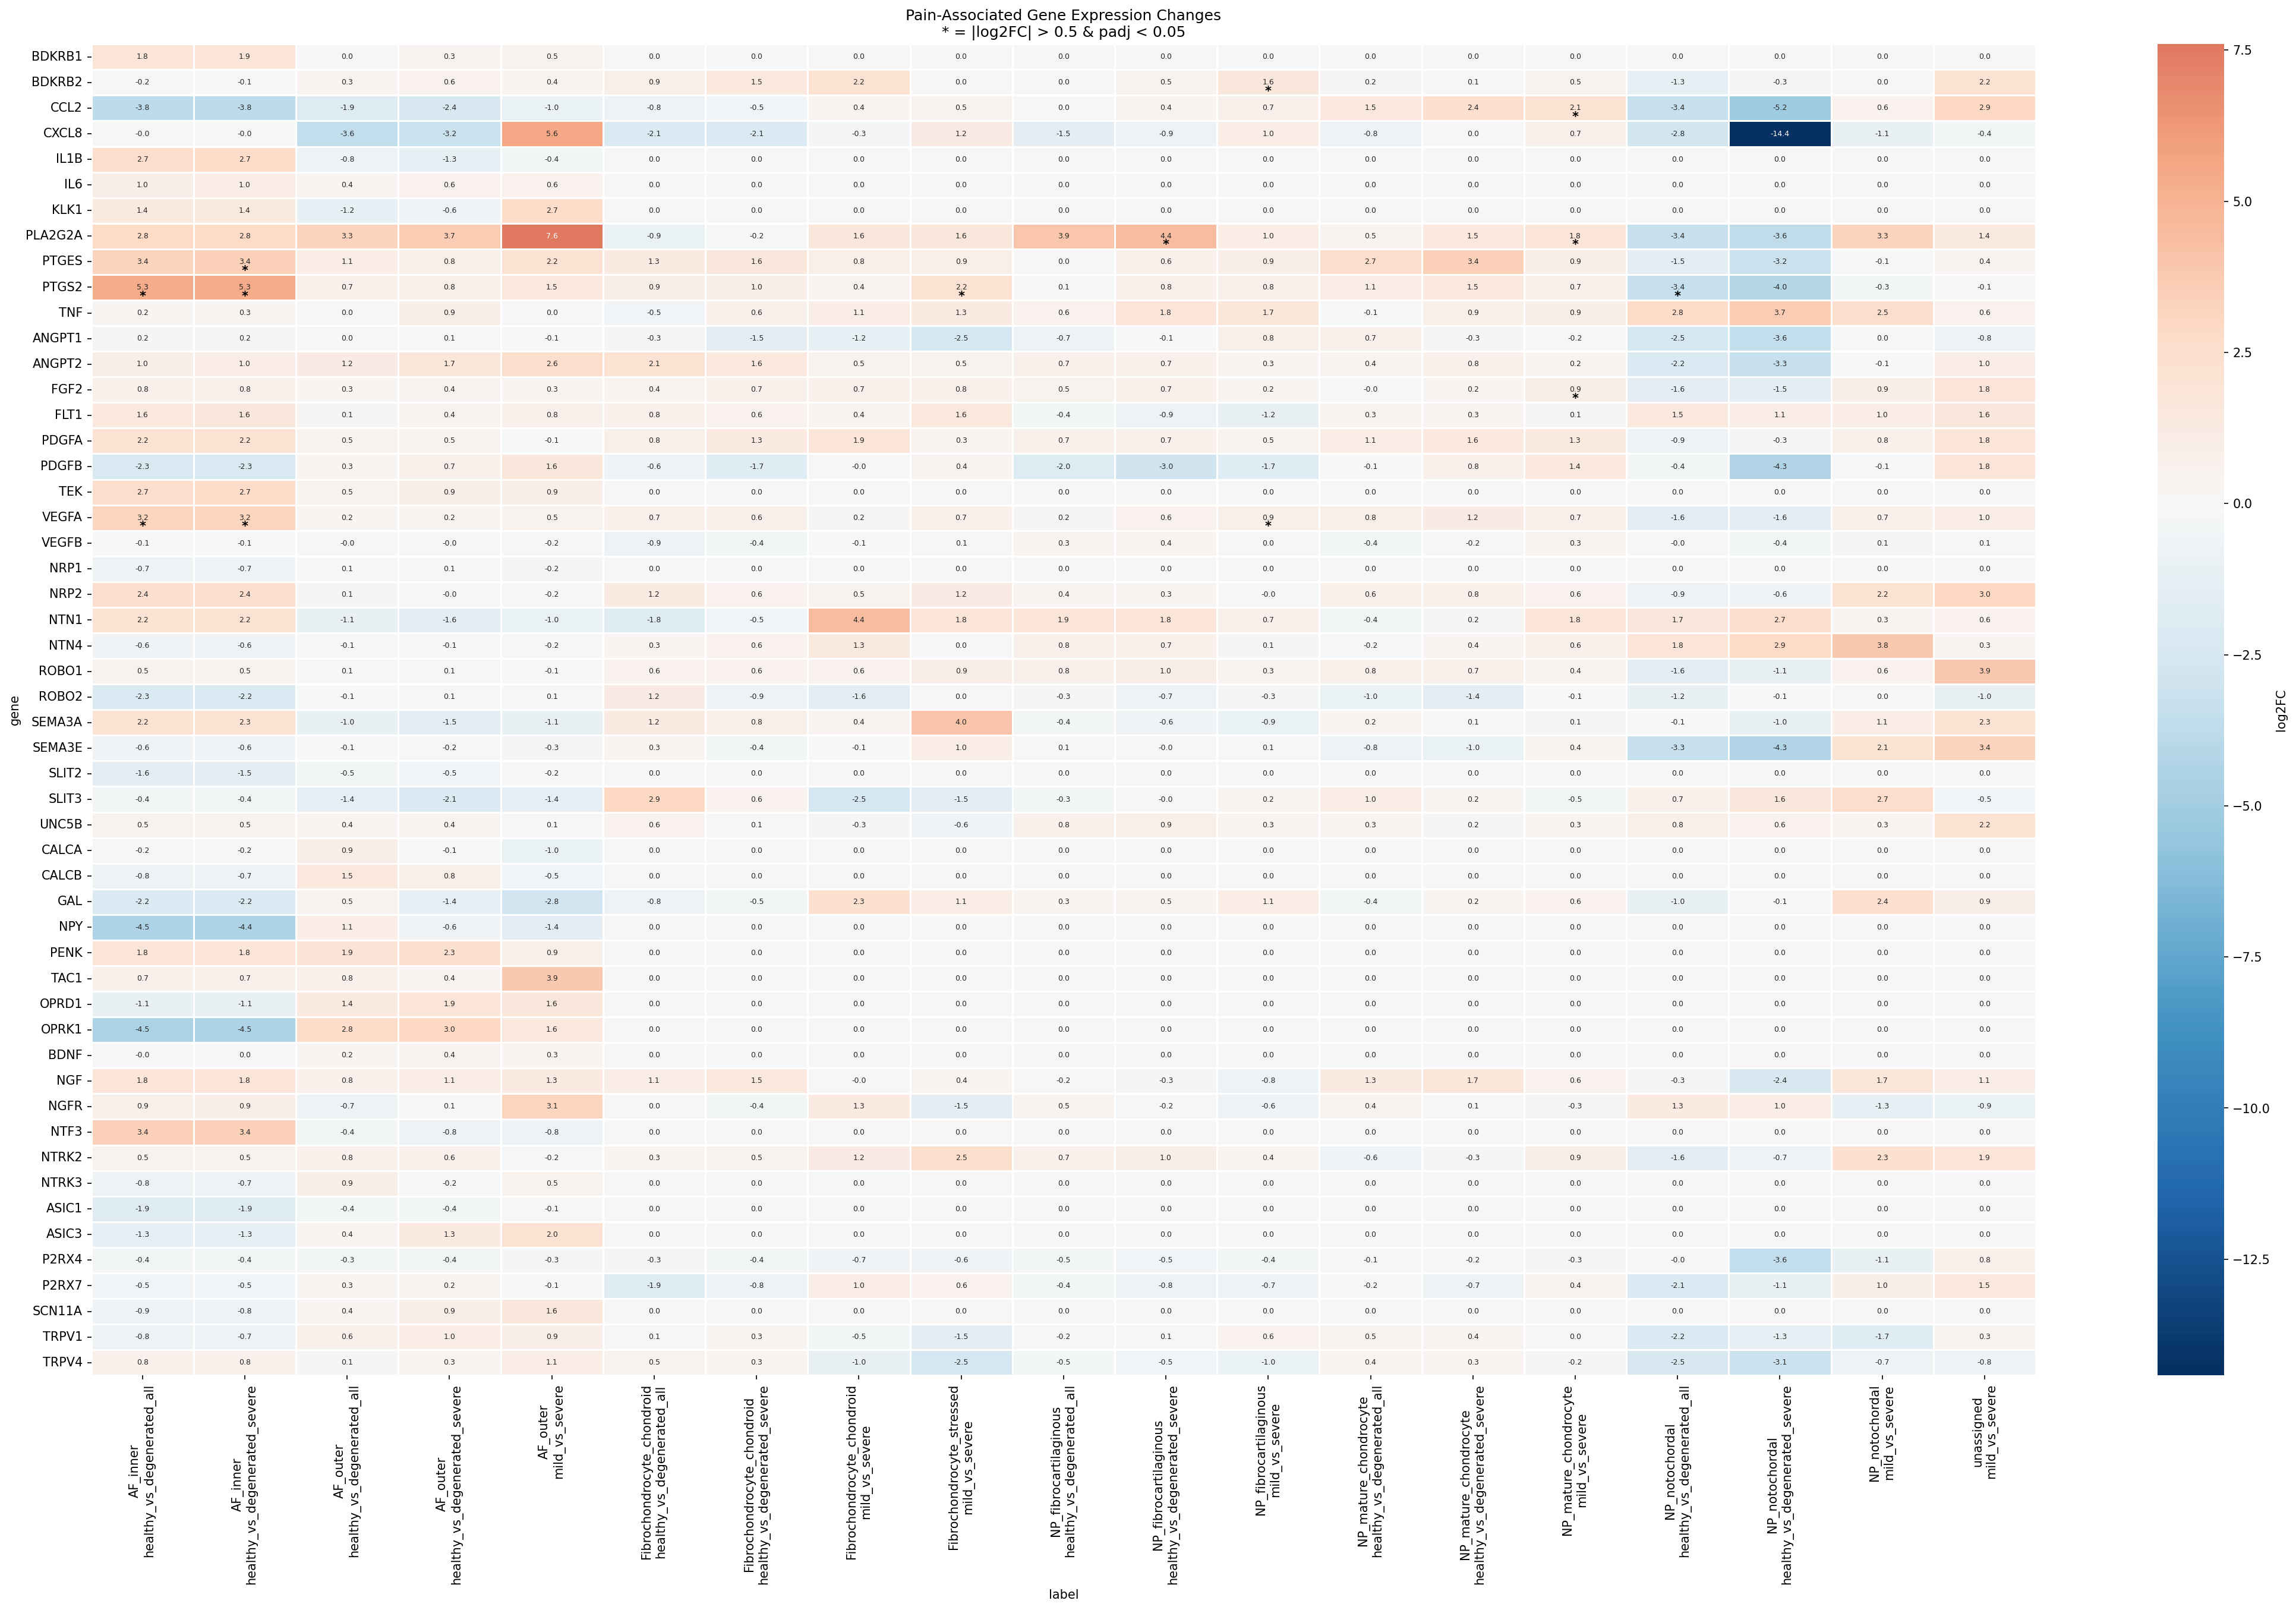

In [10]:
# Pain gene heatmap
pain_heatmap = RESULTS / 'pain_genes_heatmap.png'
if pain_heatmap.exists():
    display(Markdown('**Pain Gene Heatmap — Expression Across Cell Types and Conditions**'))
    display(Image(filename=str(pain_heatmap), width=900))
else:
    print('Pain genes heatmap not found')

## Status — Module 09 Complete (v4)

### Key biological themes
- Extracellular matrix degradation pathways upregulated in degeneration
- Inflammatory and immune signaling increased in degenerated discs
- Anabolic/repair pathways (e.g., collagen synthesis) downregulated
- Pain-related genes (inflammatory cytokines, prostaglandin mediators) show
  cell type-specific dysregulation in degeneration

### Next steps
- Module 10: Trajectory and pseudotime analysis (PAGA + DPT)
- Module 11: Cell-cell communication (LIANA)